In [1]:
%load_ext autoreload
%autoreload 2

import sys
sys.path.append(f"./../")

from qiskit import QuantumCircuit, transpile
import itertools
from qiskit.circuit.library import PauliEvolutionGate
from qiskit.quantum_info import Operator, Pauli, SparsePauliOp
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import expm
import os
import pandas as pd

from src.qwalk_dictionary import getOpsCirc
from src.misc import graph_matchings_parallel

In [2]:
# Create output directory for plots
output_dir = "trotterization_plots"
os.makedirs(output_dir, exist_ok=True)

# Set up publication-quality plotting style
plt.rcParams.update({
    'font.size': 12,
    'font.family': 'serif',
    'axes.labelsize': 14,
    'axes.titlesize': 16,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'legend.fontsize': 12,
    'figure.figsize': (8, 6),
    'lines.linewidth': 2,
    'lines.markersize': 8,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'text.usetex': False  # Set to True if you have LaTeX installed
})

In [3]:


# Global storage for gate count data
gate_count_data = []


def build_matching_circuit(n_qubits, n_steps, delta_t, matchings):
    """
    Build quantum circuit using matching-based decomposition.
    
    For each Trotter step:
        For each matching:
            For each edge in matching:
                Add single edge circuit
    
    Args:
        n_qubits: Number of qubits
        n_steps: Number of Trotter steps
        delta_t: Time step size
        relabeled_edges: List of edges in relabeled graph
        matchings: List of matchings, where each matching is a list of edges
        
    Returns:
        QuantumCircuit: Complete matching-based circuit
    """
    qc = QuantumCircuit(n_qubits)
    
    # Time per step
    dt = delta_t / n_steps
    
    # Each edge appears in exactly one matching, so we divide time by number of matchings
    # to ensure correct total evolution time
    time_per_edge = dt / len(matchings) if matchings else dt
    
    for step in range(n_steps):
        for matching in matchings:
            for edge in matching:
                # Edge nodes are already binary strings
                node1, node2 = edge
                
                # Ensure they are strings (not integers)
                if isinstance(node1, int):
                    z1 = format(node1, f'0{n_qubits}b')
                else:
                    z1 = str(node1)  # Ensure it's a string
                    
                if isinstance(node2, int):
                    z2 = format(node2, f'0{n_qubits}b')
                else:
                    z2 = str(node2)  # Ensure it's a string
                
                # Pad strings to correct length if needed
                z1 = z1.zfill(n_qubits)
                z2 = z2.zfill(n_qubits)
                
                # Get single edge circuit
                # little_endian=True matches qiskit convention
                edge_circ = getOpsCirc(z1, z2, little_endian=True, param=dt)
                
                # Add to main circuit
                qc.compose(edge_circ, inplace=True)
    
    return qc


def build_pauli_circuit(n_qubits, n_steps, delta_t, hamiltonian):
    """
    Build quantum circuit using Pauli decomposition.
    
    Args:
        n_qubits: Number of qubits
        n_steps: Number of Trotter steps
        delta_t: Time step size
        hamiltonian: Hamiltonian matrix
        
    Returns:
        QuantumCircuit: Complete Pauli-based circuit
    """
    qc = QuantumCircuit(n_qubits)
    
    # Decompose Hamiltonian into Pauli basis
    pauli_strings = []
    coeffs = []
    
    for pauli_string in ["".join(p) for p in itertools.product("IXYZ", repeat=n_qubits)]:
        P = Pauli(pauli_string)
        P_op = Operator(P).data
        coeff = np.trace(P_op.conj().T @ hamiltonian) / (2**n_qubits)
        
        real_coeff = float(np.real(coeff))
        if not np.isclose(real_coeff, 0, atol=1e-10):
            pauli_strings.append(pauli_string)
            coeffs.append(real_coeff)
    
    # Build circuit with accumulated steps
    if coeffs:
        dt = delta_t / n_steps
        
        for step in range(n_steps):
            for pauli_string, coeff in zip(pauli_strings, coeffs):
                single_pauli_op = SparsePauliOp([pauli_string], [coeff])
                evo_gate = PauliEvolutionGate(single_pauli_op, time=dt)
                qc.append(evo_gate, range(n_qubits))
    
    return qc


def build_exact_circuit(n_qubits, delta_t, hamiltonian):
    """
    Build exact quantum circuit using matrix exponential.
    
    Args:
        n_qubits: Number of qubits
        delta_t: Total time
        hamiltonian: Hamiltonian matrix
        
    Returns:
        QuantumCircuit: Exact evolution circuit
    """
    qc = QuantumCircuit(n_qubits)
    
    # Compute exact evolution operator
    exact_op = expm(-1j * hamiltonian * delta_t)
    exact_operator = Operator(exact_op)
    
    # Add as unitary gate
    qc.unitary(exact_operator, range(n_qubits), label='exact_evolution')
    
    return qc


def analyze_and_plot(edges, title, StaticGraph=None, output_dir="trotterization_plots", delta_t=0.1):
    """
    Analyze quantum time evolution errors and plot results.
    
    Args:
        edges: Original graph edges (set of tuples of binary strings)
               Example: {('00','01'), ('00','10'), ('00','11')}
        title: Plot title
        StaticGraph: (Optional) Graph class with get_adj_mat, n_qubits, draw methods
        output_dir: Directory to save plots (default: "trotterization_plots")
        delta_t: Time step size (default: 0.1)
        
    Example:
        edges = {('00','01'), ('00','10'), ('00','11')}
        analyze_and_plot(edges, "Tree Graph T4")
    """
    global gate_count_data
    
    # Create output directory if it doesn't exist
    import os
    os.makedirs(output_dir, exist_ok=True)
    
    n_steps_list = [1, 2, 5, 10, 20, 50, 100]
    
    print(f"\n{title}")
    print("="*60)
    print(f"Original edges: {edges}")
    
    # Create graph if StaticGraph is provided
    if StaticGraph is not None:
        G = StaticGraph(edges)
        print(f"Number of qubits: {G.n_qubits}")
        
        # Display original graph
        print("\nOriginal Graph:")
        try:
            display(G.draw())
        except:
            print("(Graph display not available)")
    
    # Get matchings (not relabeled edges directly)
    matchings = graph_matchings_parallel(edges)
    
    # Reconstruct relabeled edges from matchings
    relabeled_edges = set()
    for m in matchings:
        relabeled_edges = relabeled_edges.union(m)
    
    print(f"Number of matchings: {len(matchings)}")
    print(f"Matchings: {matchings}")
    print(f"Relabeled edges: {relabeled_edges}")
    
    # Infer number of qubits from edge binary strings
    if relabeled_edges:
        first_edge = next(iter(relabeled_edges))
        n_qubits = len(first_edge[0])
    else:
        raise ValueError("No edges provided")
    
    print(f"Number of qubits: {n_qubits}")
    
    # Display relabeled graph if StaticGraph is available
    if StaticGraph is not None:
        G_relabeled = StaticGraph(relabeled_edges)
        print("\nRelabeled Graph:")
        try:
            display(G_relabeled.draw())
        except:
            print("(Graph display not available)")
        
        # Get Hamiltonian from graph
        H = G_relabeled.get_adj_mat()
    else:
        # Build Hamiltonian manually from relabeled edges
        H = np.zeros((2**n_qubits, 2**n_qubits), dtype=complex)
        for edge in relabeled_edges:
            node1_str, node2_str = edge
            node1 = int(node1_str, 2)
            node2 = int(node2_str, 2)
            H[node1, node2] = 1
            H[node2, node1] = 1
    
    # Display sample circuit (with n_steps=1)
    sample_qc = build_matching_circuit(n_qubits, 1, delta_t, matchings)
    print("\nSample Quantum Circuit (n_steps=1):")
    try:
        display(sample_qc.draw('mpl'))
    except:
        print(sample_qc.draw('text'))
    
    # Build exact circuit once
    exact_qc = build_exact_circuit(n_qubits, delta_t, H)
    exact_operator = Operator(expm(-1j * H * delta_t))
    
    # Transpile exact circuit
    transpiled_exact_no_opt = transpile(exact_qc, basis_gates=['u3', 'cx'], 
                                        optimization_level=0)
    transpiled_exact_opt = transpile(exact_qc, basis_gates=['u3', 'cx'], 
                                     optimization_level=3)
    
    exact_gate_counts_no_opt = transpiled_exact_no_opt.count_ops()
    exact_gate_counts_opt = transpiled_exact_opt.count_ops()
    
    # Storage for results
    matching_vs_exact_errors = []
    pauli_vs_exact_errors = []
    matching_gates_no_opt = []
    matching_gates_opt = []
    pauli_gates_no_opt = []
    pauli_gates_opt = []
    
    # Analyze each n_steps
    for n_steps in n_steps_list:        
        # Build matching circuit
        matching_qc = build_matching_circuit(n_qubits, n_steps, delta_t, matchings)

        # Transpile matching circuit
        transpiled_matching_no_opt = transpile(matching_qc, basis_gates=['u3', 'cx'], 
                                               optimization_level=0)
        transpiled_matching_opt = transpile(matching_qc, basis_gates=['u3', 'cx'], 
                                            optimization_level=3)
        
        matching_operator = Operator(transpiled_matching_opt)
        
        matching_gate_counts_no_opt = transpiled_matching_no_opt.count_ops()
        matching_gate_counts_opt = transpiled_matching_opt.count_ops()
        
        matching_single_no_opt = matching_gate_counts_no_opt.get('u3', 0)
        matching_two_no_opt = matching_gate_counts_no_opt.get('cx', 0)
        matching_single_opt = matching_gate_counts_opt.get('u3', 0)
        matching_two_opt = matching_gate_counts_opt.get('cx', 0)
        
        matching_gates_no_opt.append({
            'u3': matching_single_no_opt, 
            'cx': matching_two_no_opt, 
            'total': matching_single_no_opt + matching_two_no_opt
        })
        matching_gates_opt.append({
            'u3': matching_single_opt, 
            'cx': matching_two_opt, 
            'total': matching_single_opt + matching_two_opt
        })
        
        # Build Pauli circuit
        pauli_qc = build_pauli_circuit(n_qubits, n_steps, delta_t, H)
        
        # Transpile Pauli circuit
        transpiled_pauli_no_opt = transpile(pauli_qc, basis_gates=['u3', 'cx'], 
                                            optimization_level=0)
        transpiled_pauli_opt = transpile(pauli_qc, basis_gates=['u3', 'cx'], 
                                         optimization_level=3)
        
        pauli_operator = Operator(transpiled_pauli_opt)
        
        pauli_gate_counts_no_opt = transpiled_pauli_no_opt.count_ops()
        pauli_gate_counts_opt = transpiled_pauli_opt.count_ops()
        
        pauli_single_no_opt = pauli_gate_counts_no_opt.get('u3', 0)
        pauli_two_no_opt = pauli_gate_counts_no_opt.get('cx', 0)
        pauli_single_opt = pauli_gate_counts_opt.get('u3', 0)
        pauli_two_opt = pauli_gate_counts_opt.get('cx', 0)
        
        pauli_gates_no_opt.append({
            'u3': pauli_single_no_opt, 
            'cx': pauli_two_no_opt, 
            'total': pauli_single_no_opt + pauli_two_no_opt
        })
        pauli_gates_opt.append({
            'u3': pauli_single_opt, 
            'cx': pauli_two_opt, 
            'total': pauli_single_opt + pauli_two_opt
        })
        
        # Store gate count data
        exact_single_no_opt = exact_gate_counts_no_opt.get('u3', 0)
        exact_two_no_opt = exact_gate_counts_no_opt.get('cx', 0)
        exact_single_opt = exact_gate_counts_opt.get('u3', 0)
        exact_two_opt = exact_gate_counts_opt.get('cx', 0)
        
        gate_count_data.extend([
            {
                'Case': title,
                'Method': 'Exact',
                'n_steps': n_steps,
                'Optimization': 'No',
                'U3_gates': exact_single_no_opt,
                'CX_gates': exact_two_no_opt,
                'Total_gates': exact_single_no_opt + exact_two_no_opt
            },
            {
                'Case': title,
                'Method': 'Exact',
                'n_steps': n_steps,
                'Optimization': 'Yes',
                'U3_gates': exact_single_opt,
                'CX_gates': exact_two_opt,
                'Total_gates': exact_single_opt + exact_two_opt
            },
            {
                'Case': title,
                'Method': 'Matching',
                'n_steps': n_steps,
                'Optimization': 'No',
                'U3_gates': matching_single_no_opt,
                'CX_gates': matching_two_no_opt,
                'Total_gates': matching_single_no_opt + matching_two_no_opt
            },
            {
                'Case': title,
                'Method': 'Matching',
                'n_steps': n_steps,
                'Optimization': 'Yes',
                'U3_gates': matching_single_opt,
                'CX_gates': matching_two_opt,
                'Total_gates': matching_single_opt + matching_two_opt
            },
            {
                'Case': title,
                'Method': 'Pauli',
                'n_steps': n_steps,
                'Optimization': 'No',
                'U3_gates': pauli_single_no_opt,
                'CX_gates': pauli_two_no_opt,
                'Total_gates': pauli_single_no_opt + pauli_two_no_opt
            },
            {
                'Case': title,
                'Method': 'Pauli',
                'n_steps': n_steps,
                'Optimization': 'Yes',
                'U3_gates': pauli_single_opt,
                'CX_gates': pauli_two_opt,
                'Total_gates': pauli_single_opt + pauli_two_opt
            }
        ])
        
        # Calculate errors
        matching_vs_exact = np.linalg.norm(matching_operator - exact_operator, ord=2)
        pauli_vs_exact = np.linalg.norm(pauli_operator - exact_operator, ord=2)
        
        matching_vs_exact_errors.append(matching_vs_exact)
        pauli_vs_exact_errors.append(pauli_vs_exact)
    
    # Print gate count summary
    print(f"\nDetailed Gate Count Summary for {title}:")
    print("="*120)
    print("n_steps | Matching No Opt (U3/CX/Total) | Matching Opt (U3/CX/Total) | "
          "Pauli No Opt (U3/CX/Total) | Pauli Opt (U3/CX/Total)")
    print("-"*120)
    
    for i, n_steps in enumerate(n_steps_list):
        print(f"{n_steps:7d} | "
              f"{matching_gates_no_opt[i]['u3']:3d}/"
              f"{matching_gates_no_opt[i]['cx']:3d}/"
              f"{matching_gates_no_opt[i]['total']:6d}              | "
              f"{matching_gates_opt[i]['u3']:3d}/"
              f"{matching_gates_opt[i]['cx']:3d}/"
              f"{matching_gates_opt[i]['total']:6d}             | "
              f"{pauli_gates_no_opt[i]['u3']:3d}/"
              f"{pauli_gates_no_opt[i]['cx']:3d}/"
              f"{pauli_gates_no_opt[i]['total']:6d}            | "
              f"{pauli_gates_opt[i]['u3']:3d}/"
              f"{pauli_gates_opt[i]['cx']:3d}/"
              f"{pauli_gates_opt[i]['total']:6d}")
    print("="*120)
    
    # Create error plot
    if "exact" not in title.lower():
        fig, ax = plt.subplots(figsize=(8, 6))
        
        ax.loglog(n_steps_list, matching_vs_exact_errors, 'o-', 
                  label='Matching-based', linewidth=2.5, markersize=8, 
                  color='#1f77b4', markerfacecolor='white', 
                  markeredgewidth=2, markeredgecolor='#1f77b4')
        ax.loglog(n_steps_list, pauli_vs_exact_errors, 's-', 
                  label='Pauli decomposition', linewidth=2.5, markersize=8, 
                  color='#d62728', markerfacecolor='white',
                  markeredgewidth=2, markeredgecolor='#d62728')
        
        ax.set_xlabel('Number of Trotter steps', fontsize=14)
        ax.set_ylabel('2-norm Operator Difference (vs exact CTQW)', fontsize=14)
        
        plot_title = title.split(":")[1].strip() if ":" in title else title
        ax.set_title(plot_title, fontsize=16, pad=20)
        
        ax.grid(True, alpha=0.3, linestyle='-', linewidth=0.5)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        
        ax.legend(loc='upper right', frameon=True, fancybox=True, shadow=True)
        
        plt.tight_layout(pad=1.5)
        
        # Save plot
        filename_base = title.lower().replace(" ", "_").replace(":", "").replace(
            "(", "").replace(")", "").replace("-", "_")
        filename_base = "_".join([part for part in filename_base.split("_") if part])
        filename = f"{output_dir}/{filename_base}_error_analysis.pdf"
        plt.savefig(filename, format='pdf', dpi=300, bbox_inches='tight')
        print(f"Error plot saved as: {filename}")
        
        plt.show()
    else:
        print("Note: Case is exact, so no error analysis is performed.")


def create_gate_count_summary_table():
    """Create comprehensive summary table of all gate counts."""
    global gate_count_data
    
    if not gate_count_data:
        print("No gate count data available.")
        return
    
    df = pd.DataFrame(gate_count_data)
    
    print("\n" + "="*100)
    print("COMPREHENSIVE GATE COUNT SUMMARY")
    print("="*100)
    
    for case in df['Case'].unique():
        print(f"\nCase: {case}")
        print("-" * 80)
        case_data = df[df['Case'] == case]
        
        for method in ['Exact', 'Matching', 'Pauli']:
            method_data = case_data[case_data['Method'] == method]
            if not method_data.empty:
                print(f"\n{method} Method:")
                print("n_steps | No Opt (U3/CX/Total) | Optimized (U3/CX/Total) | "
                      "Reduction (%)")
                print("-" * 75)
                
                for n_steps in sorted(method_data['n_steps'].unique()):
                    no_opt = method_data[(method_data['n_steps'] == n_steps) & 
                                       (method_data['Optimization'] == 'No')]
                    opt = method_data[(method_data['n_steps'] == n_steps) & 
                                    (method_data['Optimization'] == 'Yes')]
                    
                    if not no_opt.empty and not opt.empty:
                        no_opt_row = no_opt.iloc[0]
                        opt_row = opt.iloc[0]
                        
                        reduction = (100 * (1 - opt_row['Total_gates'] / 
                                           no_opt_row['Total_gates']) 
                                    if no_opt_row['Total_gates'] > 0 else 0)
                        
                        print(f"{n_steps:7d} | "
                              f"{no_opt_row['U3_gates']:3d}/"
                              f"{no_opt_row['CX_gates']:3d}/"
                              f"{no_opt_row['Total_gates']:6d}      | "
                              f"{opt_row['U3_gates']:3d}/"
                              f"{opt_row['CX_gates']:3d}/"
                              f"{opt_row['Total_gates']:6d}        | "
                              f"{reduction:8.1f}")
        
        print("-" * 80)


Cycle Graph C4
Original edges: {('00', '10'), ('10', '11'), ('00', '01'), ('01', '11')}
Number of matchings: 2
Matchings: [{('01', '11'), ('00', '10')}, {('01', '00'), ('11', '10')}]
Relabeled edges: {('01', '00'), ('11', '10'), ('01', '11'), ('00', '10')}
Number of qubits: 2

Sample Quantum Circuit (n_steps=1):


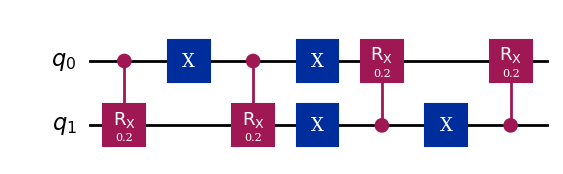


Detailed Gate Count Summary for Cycle Graph C4:
n_steps | Matching No Opt (U3/CX/Total) | Matching Opt (U3/CX/Total) | Pauli No Opt (U3/CX/Total) | Pauli Opt (U3/CX/Total)
------------------------------------------------------------------------------------------------------------------------
      1 |  16/  8/    24              |   2/  0/     2             |   2/  0/     2            |   2/  0/     2
      2 |  32/ 16/    48              |   2/  0/     2             |   4/  0/     4            |   2/  0/     2
      5 |  80/ 40/   120              |   2/  0/     2             |  10/  0/    10            |   2/  0/     2
     10 | 160/ 80/   240              |   2/  0/     2             |  20/  0/    20            |   2/  0/     2
     20 | 320/160/   480              |   2/  0/     2             |  40/  0/    40            |   2/  0/     2
     50 | 800/400/  1200              |   2/  0/     2             | 100/  0/   100            |   2/  0/     2
    100 | 1600/800/  2400         

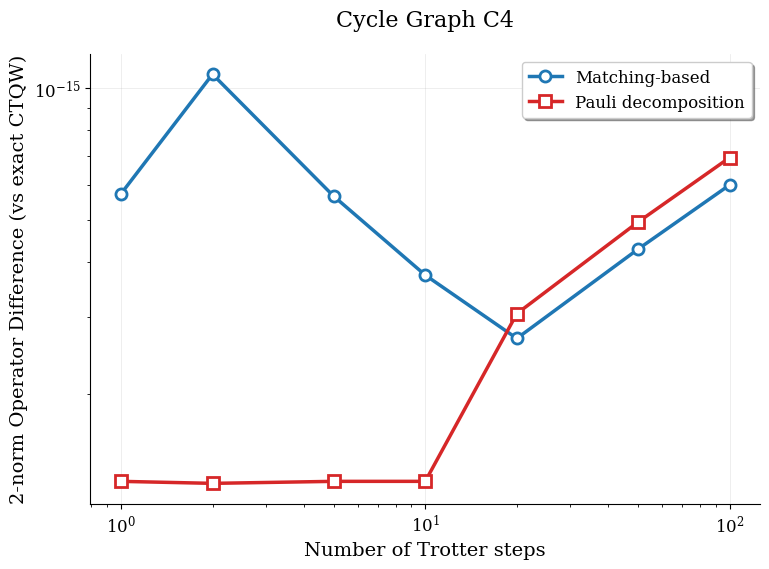

In [4]:
edges = {('00', '10'), ('01', '11'), ('10', '11'), ('00', '01')}
analyze_and_plot(edges, "Cycle Graph C4")


Complete Graph K4 - C2
Original edges: {('01', '10'), ('01', '11'), ('00', '10'), ('00', '11'), ('00', '01')}
Number of matchings: 3
Matchings: [{('01', '11'), ('10', '00')}, {('01', '00'), ('10', '11')}, {('10', '01')}]
Relabeled edges: {('01', '00'), ('10', '01'), ('01', '11'), ('10', '11'), ('10', '00')}
Number of qubits: 2

Sample Quantum Circuit (n_steps=1):


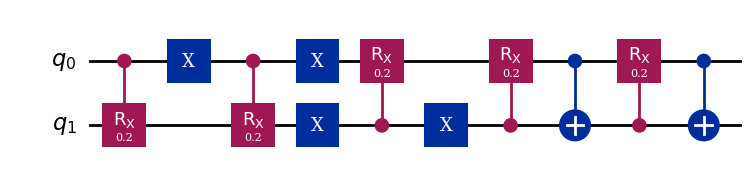


Detailed Gate Count Summary for Complete Graph K4 - C2:
n_steps | Matching No Opt (U3/CX/Total) | Matching Opt (U3/CX/Total) | Pauli No Opt (U3/CX/Total) | Pauli Opt (U3/CX/Total)
------------------------------------------------------------------------------------------------------------------------
      1 |  19/ 12/    31              |   6/  2/     8             |  12/  4/    16            |   6/  2/     8
      2 |  38/ 24/    62              |   8/  3/    11             |  24/  8/    32            |   8/  3/    11
      5 |  95/ 60/   155              |   8/  3/    11             |  60/ 20/    80            |   8/  3/    11
     10 | 190/120/   310              |   8/  3/    11             | 120/ 40/   160            |   8/  3/    11
     20 | 380/240/   620              |   8/  3/    11             | 240/ 80/   320            |   8/  3/    11
     50 | 950/600/  1550              |   8/  3/    11             | 600/200/   800            |   8/  3/    11
    100 | 1900/1200/  3100

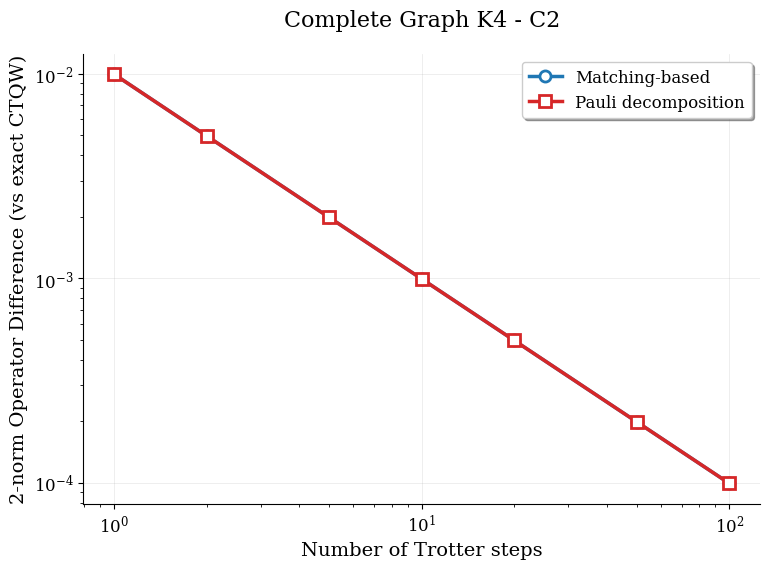

In [5]:
edges = {('00', '11'), ('01', '10'), ('00', '10'), ('01', '11'), ('00', '01')}
analyze_and_plot(edges, "Complete Graph K4 - C2")


Path Graph P3
Original edges: {('01', '10'), ('10', '11'), ('00', '01')}
Number of matchings: 2
Matchings: [{('11', '01')}, {('01', '00'), ('10', '11')}]
Relabeled edges: {('01', '00'), ('10', '11'), ('11', '01')}
Number of qubits: 2

Sample Quantum Circuit (n_steps=1):


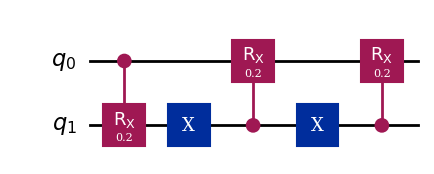


Detailed Gate Count Summary for Path Graph P3:
n_steps | Matching No Opt (U3/CX/Total) | Matching Opt (U3/CX/Total) | Pauli No Opt (U3/CX/Total) | Pauli Opt (U3/CX/Total)
------------------------------------------------------------------------------------------------------------------------
      1 |  11/  6/    17              |   6/  2/     8             |   5/  2/     7            |   4/  2/     6
      2 |  22/ 12/    34              |   6/  2/     8             |  10/  4/    14            |   6/  2/     8
      5 |  55/ 30/    85              |   6/  2/     8             |  25/ 10/    35            |   6/  2/     8
     10 | 110/ 60/   170              |   6/  2/     8             |  50/ 20/    70            |   6/  2/     8
     20 | 220/120/   340              |   6/  2/     8             | 100/ 40/   140            |   6/  2/     8
     50 | 550/300/   850              |   6/  2/     8             | 250/100/   350            |   6/  2/     8
    100 | 1100/600/  1700          

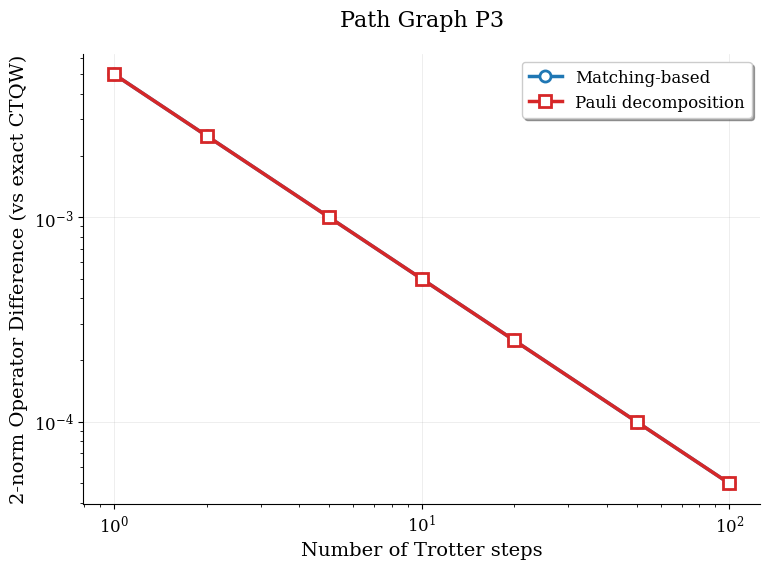

In [6]:
edges = {('00', '01'), ('01', '10'), ('10', '11')}
analyze_and_plot(edges, "Path Graph P3")


Tree Graph (2 qubits)
Original edges: {('00', '01'), ('00', '10'), ('00', '11')}
Number of matchings: 3
Matchings: [{('01', '10')}, {('01', '11')}, {('01', '00')}]
Relabeled edges: {('01', '00'), ('01', '10'), ('01', '11')}
Number of qubits: 2

Sample Quantum Circuit (n_steps=1):


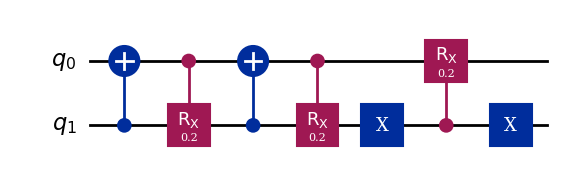


Detailed Gate Count Summary for Tree Graph (2 qubits):
n_steps | Matching No Opt (U3/CX/Total) | Matching Opt (U3/CX/Total) | Pauli No Opt (U3/CX/Total) | Pauli Opt (U3/CX/Total)
------------------------------------------------------------------------------------------------------------------------
      1 |  11/  8/    19              |   8/  3/    11             |  18/  8/    26            |   8/  3/    11
      2 |  22/ 16/    38              |   8/  3/    11             |  36/ 16/    52            |   8/  3/    11
      5 |  55/ 40/    95              |   8/  3/    11             |  90/ 40/   130            |   8/  3/    11
     10 | 110/ 80/   190              |   8/  3/    11             | 180/ 80/   260            |   8/  3/    11
     20 | 220/160/   380              |   8/  3/    11             | 360/160/   520            |   8/  3/    11
     50 | 550/400/   950              |   8/  3/    11             | 900/400/  1300            |   8/  3/    11
    100 | 1100/800/  1900  

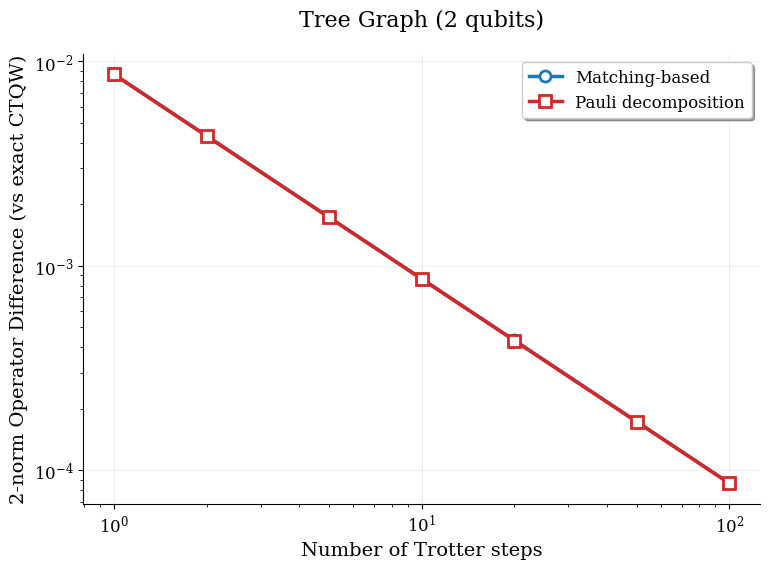

In [7]:
edges = {('00','01'), ('00','10'), ('00','11')}
analyze_and_plot(edges, "Tree Graph (2 qubits)")


Tree Graph (3 qubits)
Original edges: {('000', '101'), ('000', '111'), ('000', '110'), ('000', '001'), ('000', '010'), ('000', '100'), ('000', '011')}
Number of matchings: 7
Matchings: [{('001', '010')}, {('001', '100')}, {('001', '111')}, {('001', '110')}, {('001', '101')}, {('001', '011')}, {('001', '000')}]
Relabeled edges: {('001', '010'), ('001', '100'), ('001', '000'), ('001', '011'), ('001', '101'), ('001', '111'), ('001', '110')}
Number of qubits: 3

Sample Quantum Circuit (n_steps=1):


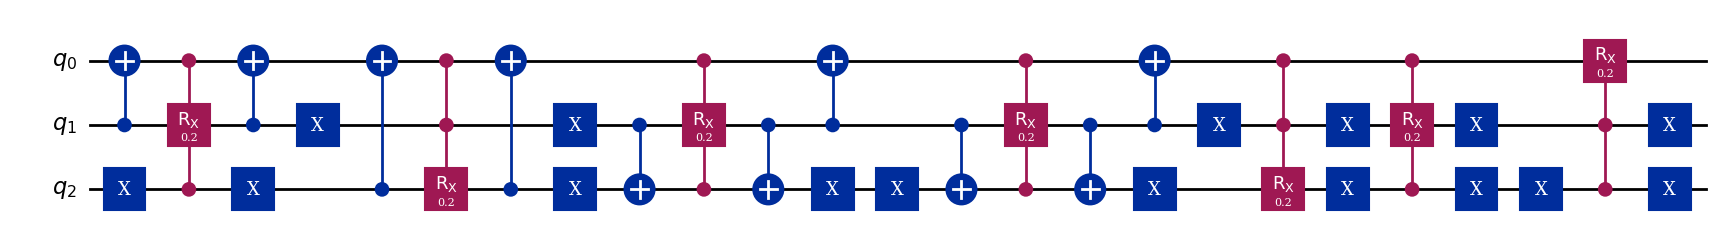


Detailed Gate Count Summary for Tree Graph (3 qubits):
n_steps | Matching No Opt (U3/CX/Total) | Matching Opt (U3/CX/Total) | Pauli No Opt (U3/CX/Total) | Pauli Opt (U3/CX/Total)
------------------------------------------------------------------------------------------------------------------------
      1 | 121/ 66/   187              |  63/ 60/   123             | 118/ 76/   194            |  55/ 30/    85
      2 | 242/132/   374              | 127/119/   246             | 236/152/   388            | 109/ 60/   169
      5 | 605/330/   935              | 316/296/   612             | 590/380/   970            | 271/150/   421
     10 | 1210/660/  1870              | 631/591/  1222             | 1180/760/  1940            | 521/300/   821
     20 | 2420/1320/  3740              | 1261/1181/  2442             | 2360/1520/  3880            | 1081/600/  1681
     50 | 6050/3300/  9350              | 3151/2951/  6102             | 5900/3800/  9700            | 2701/1500/  4201
    100 | 

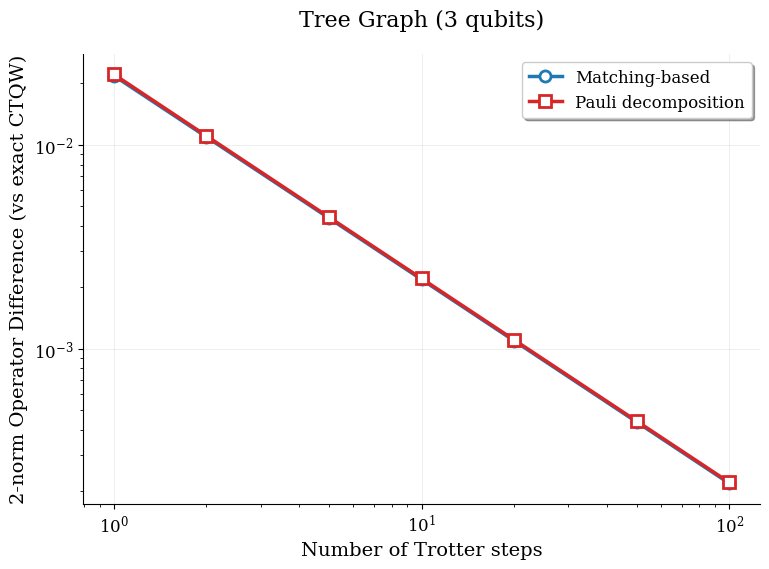

In [8]:
edges = {('000','001'), ('000','010'), ('000','011'), ('000','100'), ('000','101'), ('000','110'), ('000','111')}
analyze_and_plot(edges, "Tree Graph (3 qubits)")


Dense Non-Bipartite Graph (3 qubits)
Original edges: {('101', '111'), ('000', '101'), ('011', '111'), ('000', '110'), ('000', '001'), ('001', '101'), ('000', '100'), ('010', '110'), ('001', '100'), ('100', '111'), ('010', '100'), ('110', '111'), ('000', '011'), ('001', '011'), ('011', '101'), ('101', '110'), ('010', '011'), ('001', '111'), ('011', '100'), ('000', '010'), ('010', '111'), ('001', '010'), ('100', '101'), ('100', '110')}
Number of matchings: 7
Matchings: [{('100', '110'), ('101', '111'), ('001', '011'), ('000', '010')}, {('001', '100'), ('000', '101'), ('010', '111')}, {('001', '010'), ('100', '111'), ('011', '101'), ('000', '110')}, {('101', '110'), ('001', '111'), ('010', '100'), ('000', '011')}, {('011', '100')}, {('001', '101'), ('000', '100'), ('011', '111'), ('010', '110')}, {('100', '101'), ('000', '001'), ('110', '111'), ('010', '011')}]
Relabeled edges: {('101', '111'), ('000', '101'), ('011', '111'), ('000', '110'), ('000', '001'), ('001', '101'), ('000', '100')

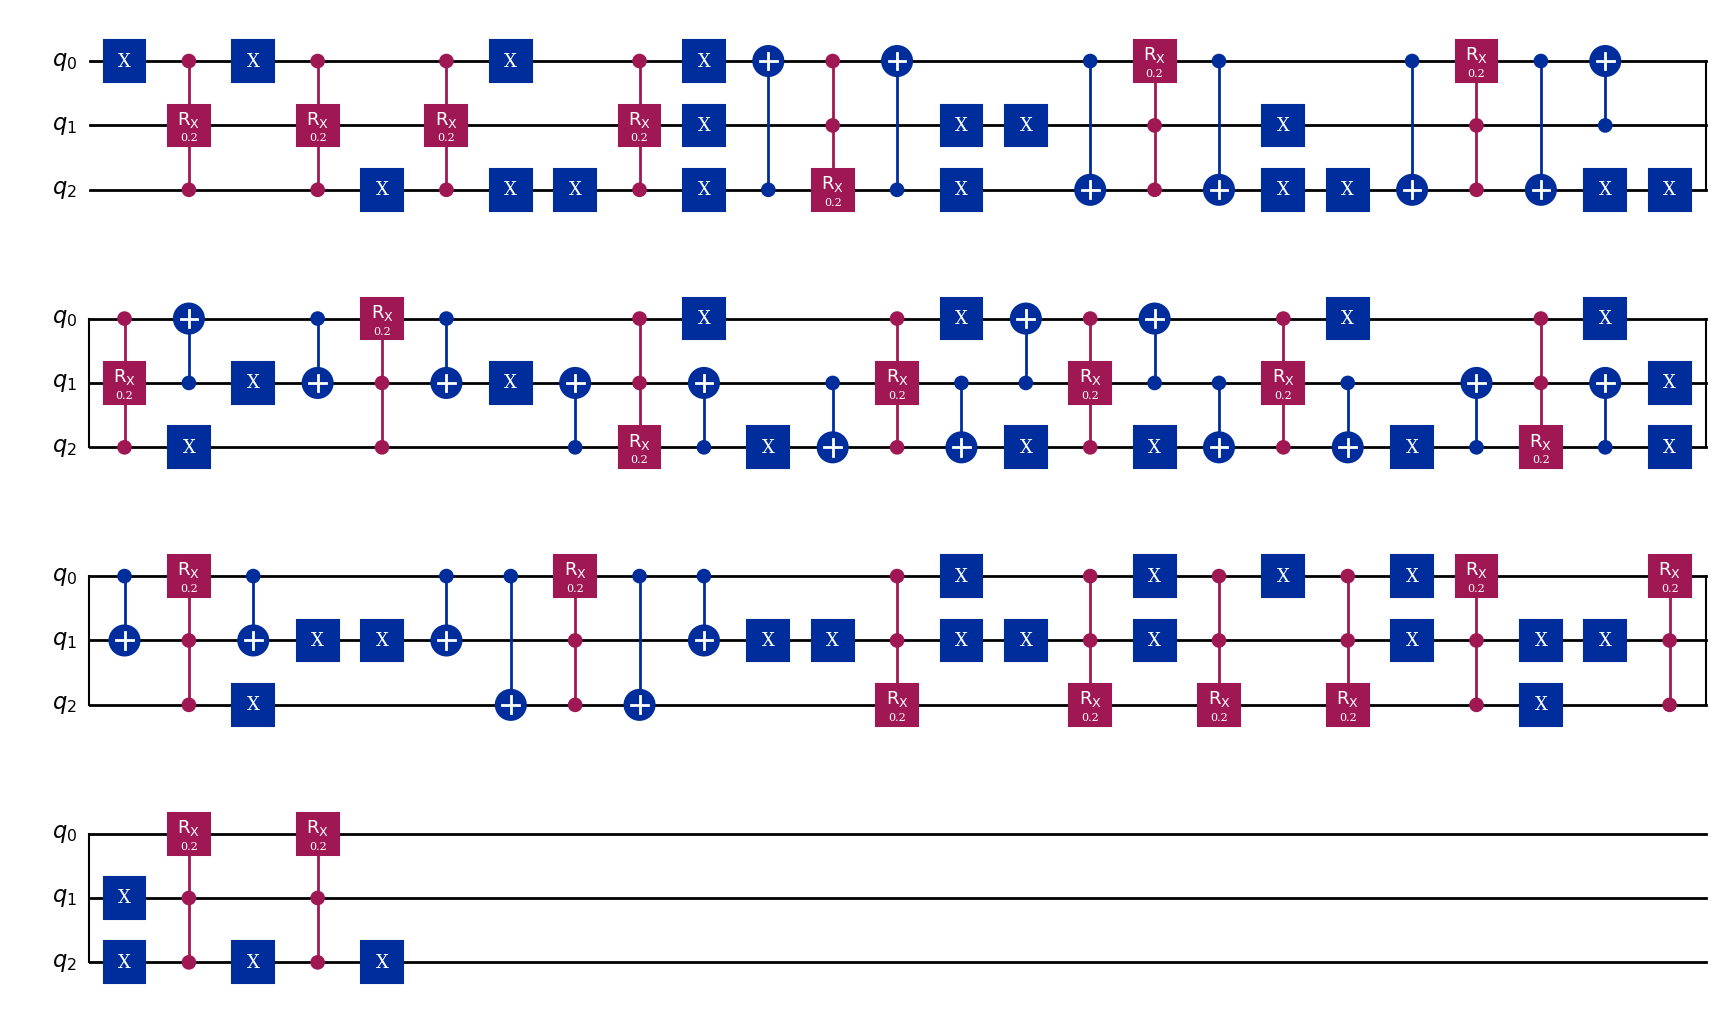


Detailed Gate Count Summary for Dense Non-Bipartite Graph (3 qubits):
n_steps | Matching No Opt (U3/CX/Total) | Matching Opt (U3/CX/Total) | Pauli No Opt (U3/CX/Total) | Pauli Opt (U3/CX/Total)
------------------------------------------------------------------------------------------------------------------------
      1 | 410/218/   628              | 207/200/   407             |  61/ 32/    93            |  31/ 20/    51
      2 | 820/436/  1256              | 413/400/   813             | 122/ 64/   186            |  62/ 40/   102
      5 | 2050/1090/  3140              | 1031/1000/  2031             | 305/160/   465            | 152/100/   252
     10 | 4100/2180/  6280              | 2061/2000/  4061             | 610/320/   930            | 302/200/   502
     20 | 8200/4360/ 12560              | 4121/4000/  8121             | 1220/640/  1860            | 602/400/  1002
     50 | 20500/10900/ 31400              | 10301/10000/ 20301             | 3050/1600/  4650            | 1452

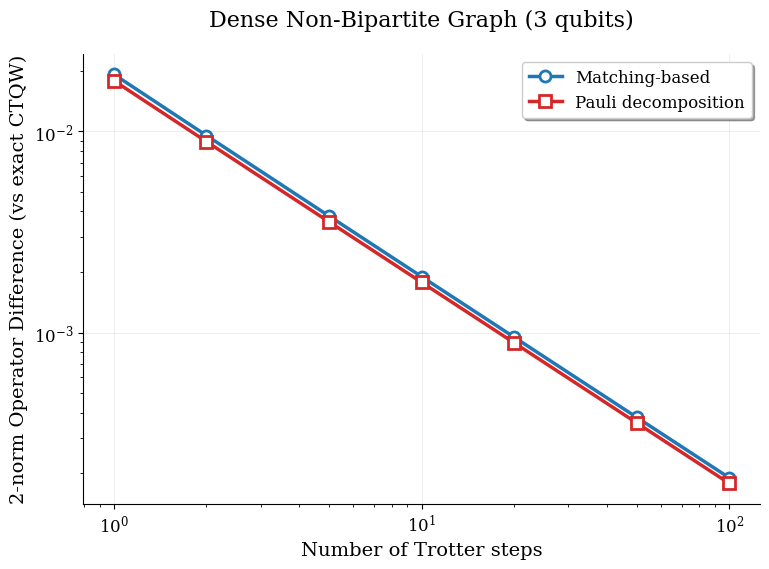

In [9]:
dense_nonbipartite_8 = {
    ('000','001'), ('000','010'), ('000','011'), ('000','100'), ('000','101'), ('000','110'),
    ('001','010'), ('001','011'), ('001','100'), ('001','101'), ('001','111'),
    ('010','011'), ('010','100'), ('010','110'), ('010','111'),
    ('011','100'), ('011','101'), ('011','111'),
    ('100','101'), ('100','110'), ('100','111'),
    ('101','110'), ('101','111'),
    ('110','111')
}

analyze_and_plot(dense_nonbipartite_8, "Dense Non-Bipartite Graph (3 qubits)")


Dense Bipartite Graph (3 qubits)
Original edges: {('000', '101'), ('011', '111'), ('000', '110'), ('001', '101'), ('000', '100'), ('001', '110'), ('010', '101'), ('010', '110'), ('001', '100'), ('010', '100'), ('011', '101'), ('000', '111'), ('011', '110'), ('001', '111'), ('011', '100'), ('010', '111')}
Number of matchings: 4
Matchings: [{('100', '000'), ('010', '110'), ('001', '101'), ('111', '011')}, {('100', '101'), ('010', '011'), ('001', '000'), ('111', '110')}, {('100', '110'), ('001', '011'), ('111', '101'), ('010', '000')}, {('100', '011'), ('001', '110'), ('010', '101'), ('111', '000')}]
Relabeled edges: {('100', '000'), ('001', '011'), ('010', '011'), ('111', '000'), ('001', '101'), ('100', '011'), ('001', '110'), ('010', '101'), ('010', '110'), ('111', '011'), ('100', '101'), ('100', '110'), ('111', '101'), ('111', '110'), ('001', '000'), ('010', '000')}
Number of qubits: 3

Sample Quantum Circuit (n_steps=1):


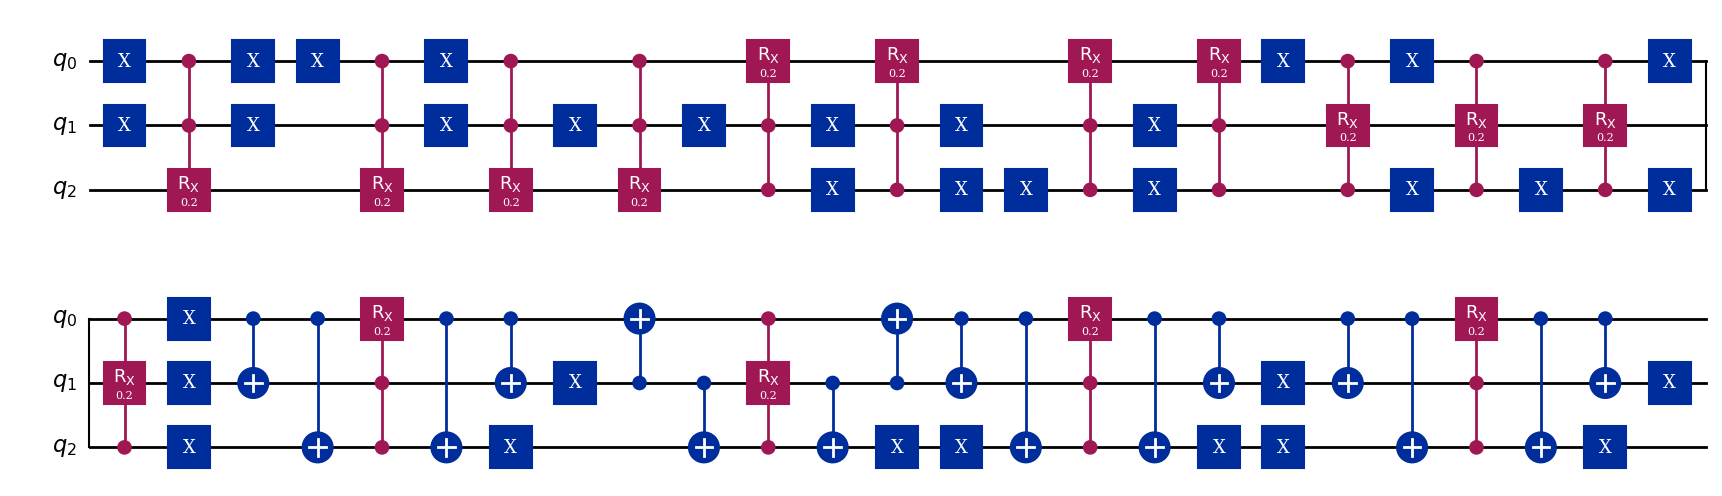


Detailed Gate Count Summary for Dense Bipartite Graph (3 qubits):
n_steps | Matching No Opt (U3/CX/Total) | Matching Opt (U3/CX/Total) | Pauli No Opt (U3/CX/Total) | Pauli Opt (U3/CX/Total)
------------------------------------------------------------------------------------------------------------------------
      1 | 274/144/   418              | 134/134/   268             |  10/  4/    14            |   7/  4/    11
      2 | 548/288/   836              | 265/268/   533             |  20/  8/    28            |  11/  8/    19
      5 | 1370/720/  2090              | 658/670/  1328             |  50/ 20/    70            |  23/ 20/    43
     10 | 2740/1440/  4180              | 1313/1340/  2653             | 100/ 40/   140            |  43/ 40/    83
     20 | 5480/2880/  8360              | 2603/2680/  5283             | 200/ 80/   280            |  83/ 80/   163
     50 | 13700/7200/ 20900              | 6553/6700/ 13253             | 500/200/   700            | 203/200/   403
  

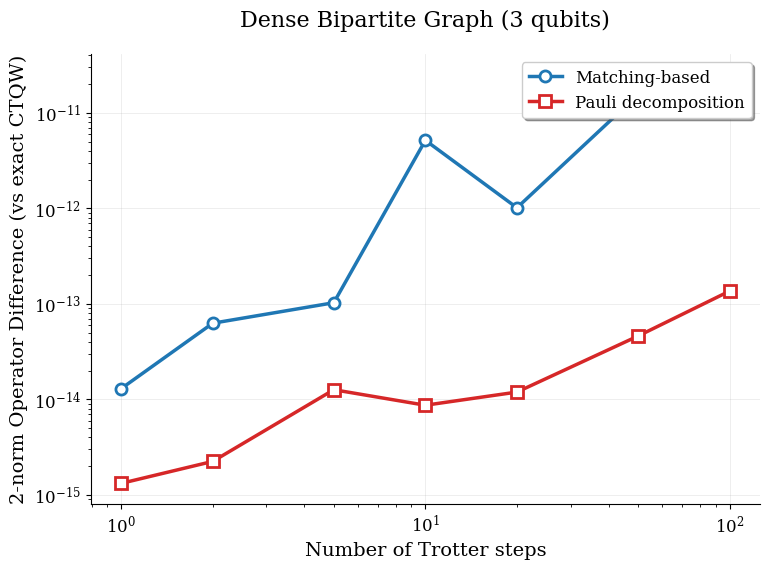

In [10]:
dense_bipartite_8 = {
    ('000','100'), ('000','101'), ('000','110'), ('000','111'),
    ('001','100'), ('001','101'), ('001','110'), ('001','111'),
    ('010','100'), ('010','101'), ('010','110'), ('010','111'),
    ('011','100'), ('011','101'), ('011','110'), ('011','111')  
}
analyze_and_plot(dense_bipartite_8, "Dense Bipartite Graph (3 qubits)")


Sparse Non-Bipartite Graph (3 qubits)
Original edges: {('001', '010'), ('100', '101'), ('101', '011'), ('000', '001'), ('110', '111'), ('011', '100'), ('010', '000')}
Number of matchings: 4
Matchings: [{('100', '101'), ('110', '111'), ('011', '010')}, {('101', '001')}, {('001', '100'), ('000', '011')}, {('010', '000')}]
Relabeled edges: {('100', '101'), ('001', '100'), ('010', '000'), ('011', '010'), ('101', '001'), ('110', '111'), ('000', '011')}
Number of qubits: 3

Sample Quantum Circuit (n_steps=1):


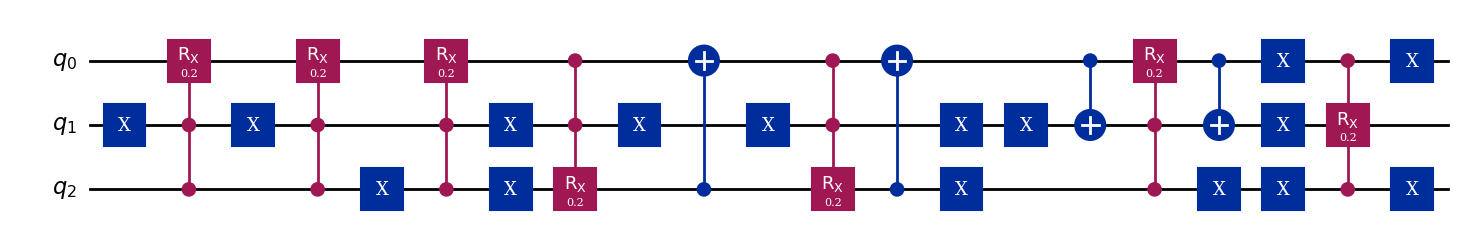


Detailed Gate Count Summary for Sparse Non-Bipartite Graph (3 qubits):
n_steps | Matching No Opt (U3/CX/Total) | Matching Opt (U3/CX/Total) | Pauli No Opt (U3/CX/Total) | Pauli Opt (U3/CX/Total)
------------------------------------------------------------------------------------------------------------------------
      1 | 121/ 60/   181              |  60/ 57/   117             |  70/ 48/   118            |  40/ 24/    64
      2 | 242/120/   362              | 118/114/   232             | 140/ 96/   236            |  79/ 48/   127
      5 | 605/300/   905              | 292/285/   577             | 350/240/   590            | 196/120/   316
     10 | 1210/600/  1810              | 582/570/  1152             | 700/480/  1180            | 391/240/   631
     20 | 2420/1200/  3620              | 1162/1140/  2302             | 1400/960/  2360            | 781/480/  1261
     50 | 6050/3000/  9050              | 2902/2850/  5752             | 3500/2400/  5900            | 1951/1200/  31

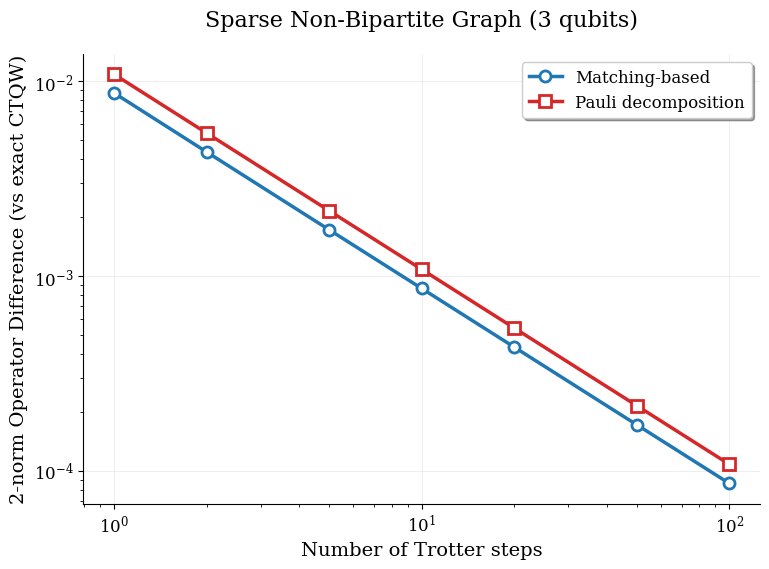

In [11]:
sparse_nonbipartite_8 = {
    ('000','001'), ('001','010'), ('010','000'),  # Triangle (odd cycle)
    ('011','100'), ('100','101'), ('101','011'),  # Another triangle
    ('110','111')
}
analyze_and_plot(sparse_nonbipartite_8, "Sparse Non-Bipartite Graph (3 qubits)")


Sparse Bipartite Graph (3 qubits)
Original edges: {('100', '101'), ('010', '001'), ('110', '101'), ('010', '011'), ('000', '001'), ('100', '011'), ('110', '111')}
Number of matchings: 4
Matchings: [{('100', '101'), ('000', '001')}, {('010', '001'), ('011', '101')}, {('011', '111'), ('010', '110')}, {('100', '110')}]
Relabeled edges: {('100', '101'), ('010', '001'), ('100', '110'), ('011', '101'), ('011', '111'), ('000', '001'), ('010', '110')}
Number of qubits: 3

Sample Quantum Circuit (n_steps=1):


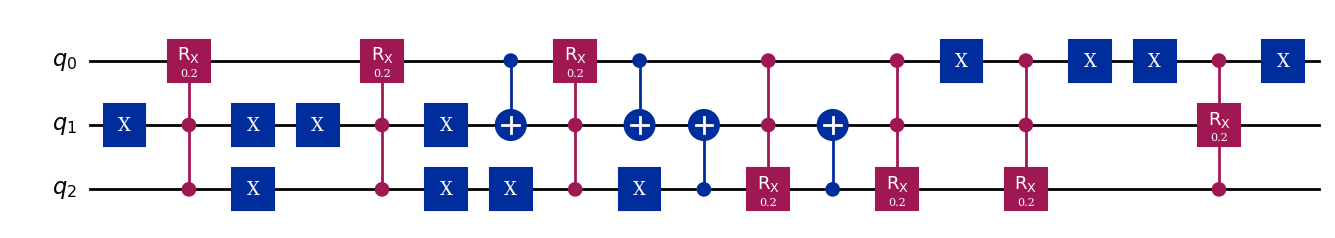


Detailed Gate Count Summary for Sparse Bipartite Graph (3 qubits):
n_steps | Matching No Opt (U3/CX/Total) | Matching Opt (U3/CX/Total) | Pauli No Opt (U3/CX/Total) | Pauli Opt (U3/CX/Total)
------------------------------------------------------------------------------------------------------------------------
      1 | 117/ 60/   177              |  60/ 56/   116             |  58/ 36/    94            |  32/ 18/    50
      2 | 234/120/   354              | 118/112/   230             | 116/ 72/   188            |  61/ 36/    97
      5 | 585/300/   885              | 287/280/   567             | 290/180/   470            | 153/ 90/   243
     10 | 1170/600/  1770              | 572/560/  1132             | 580/360/   940            | 312/180/   492
     20 | 2340/1200/  3540              | 1162/1120/  2282             | 1160/720/  1880            | 602/360/   962
     50 | 5850/3000/  8850              | 2902/2800/  5702             | 2900/1800/  4700            | 1453/900/  2353
  

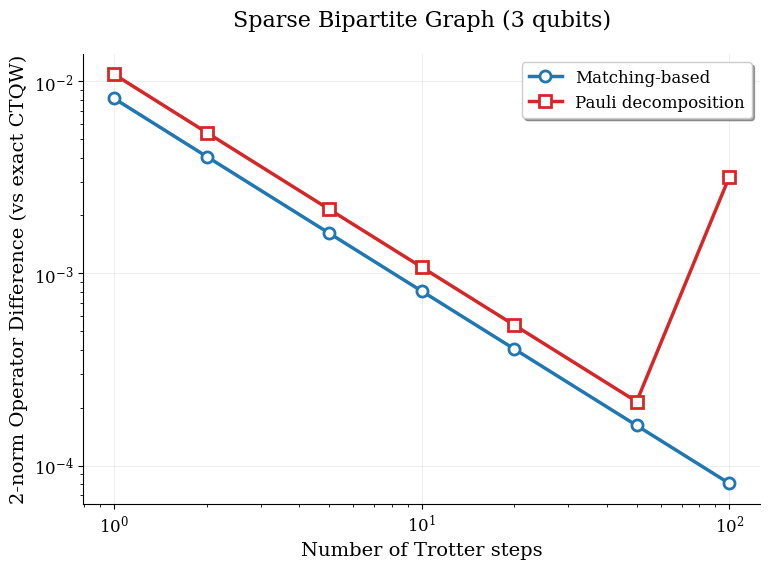

In [12]:
sparse_bipartite_8 = {
    ('000','001'), ('010','001'), ('010','011'), ('100','011'), ('100','101'), ('110','101'), ('110','111')
}
analyze_and_plot(sparse_bipartite_8, "Sparse Bipartite Graph (3 qubits)")


Dense Non-Bipartite Graph (4 qubits)
Original edges: {('1011', '1101'), ('1000', '1100'), ('1011', '1100'), ('1001', '1101'), ('0000', '0010'), ('0000', '0011'), ('0000', '0101'), ('0000', '0110'), ('0110', '1100'), ('0001', '1001'), ('0000', '0001'), ('0110', '0111'), ('0111', '1011'), ('0001', '0010'), ('0001', '0011'), ('0001', '0101'), ('0110', '1110'), ('0000', '0100'), ('1000', '1001'), ('0100', '0110'), ('0001', '1000'), ('0101', '1101'), ('0100', '0101'), ('1101', '1110'), ('1101', '1111'), ('0100', '1000'), ('0001', '0100'), ('1100', '1110'), ('1100', '1111'), ('1000', '1011'), ('0010', '0011'), ('1010', '1110'), ('0010', '0110'), ('1010', '1111'), ('1001', '1011'), ('1100', '1101'), ('0010', '1000'), ('0100', '1100'), ('0101', '0111'), ('0011', '0111'), ('1010', '1100'), ('0101', '1001'), ('0010', '0100'), ('0011', '1001'), ('0111', '1111'), ('0100', '1010'), ('0101', '1011'), ('0101', '0110'), ('0111', '1101'), ('1000', '1010'), ('0010', '1010'), ('0000', '0111'), ('0011', 

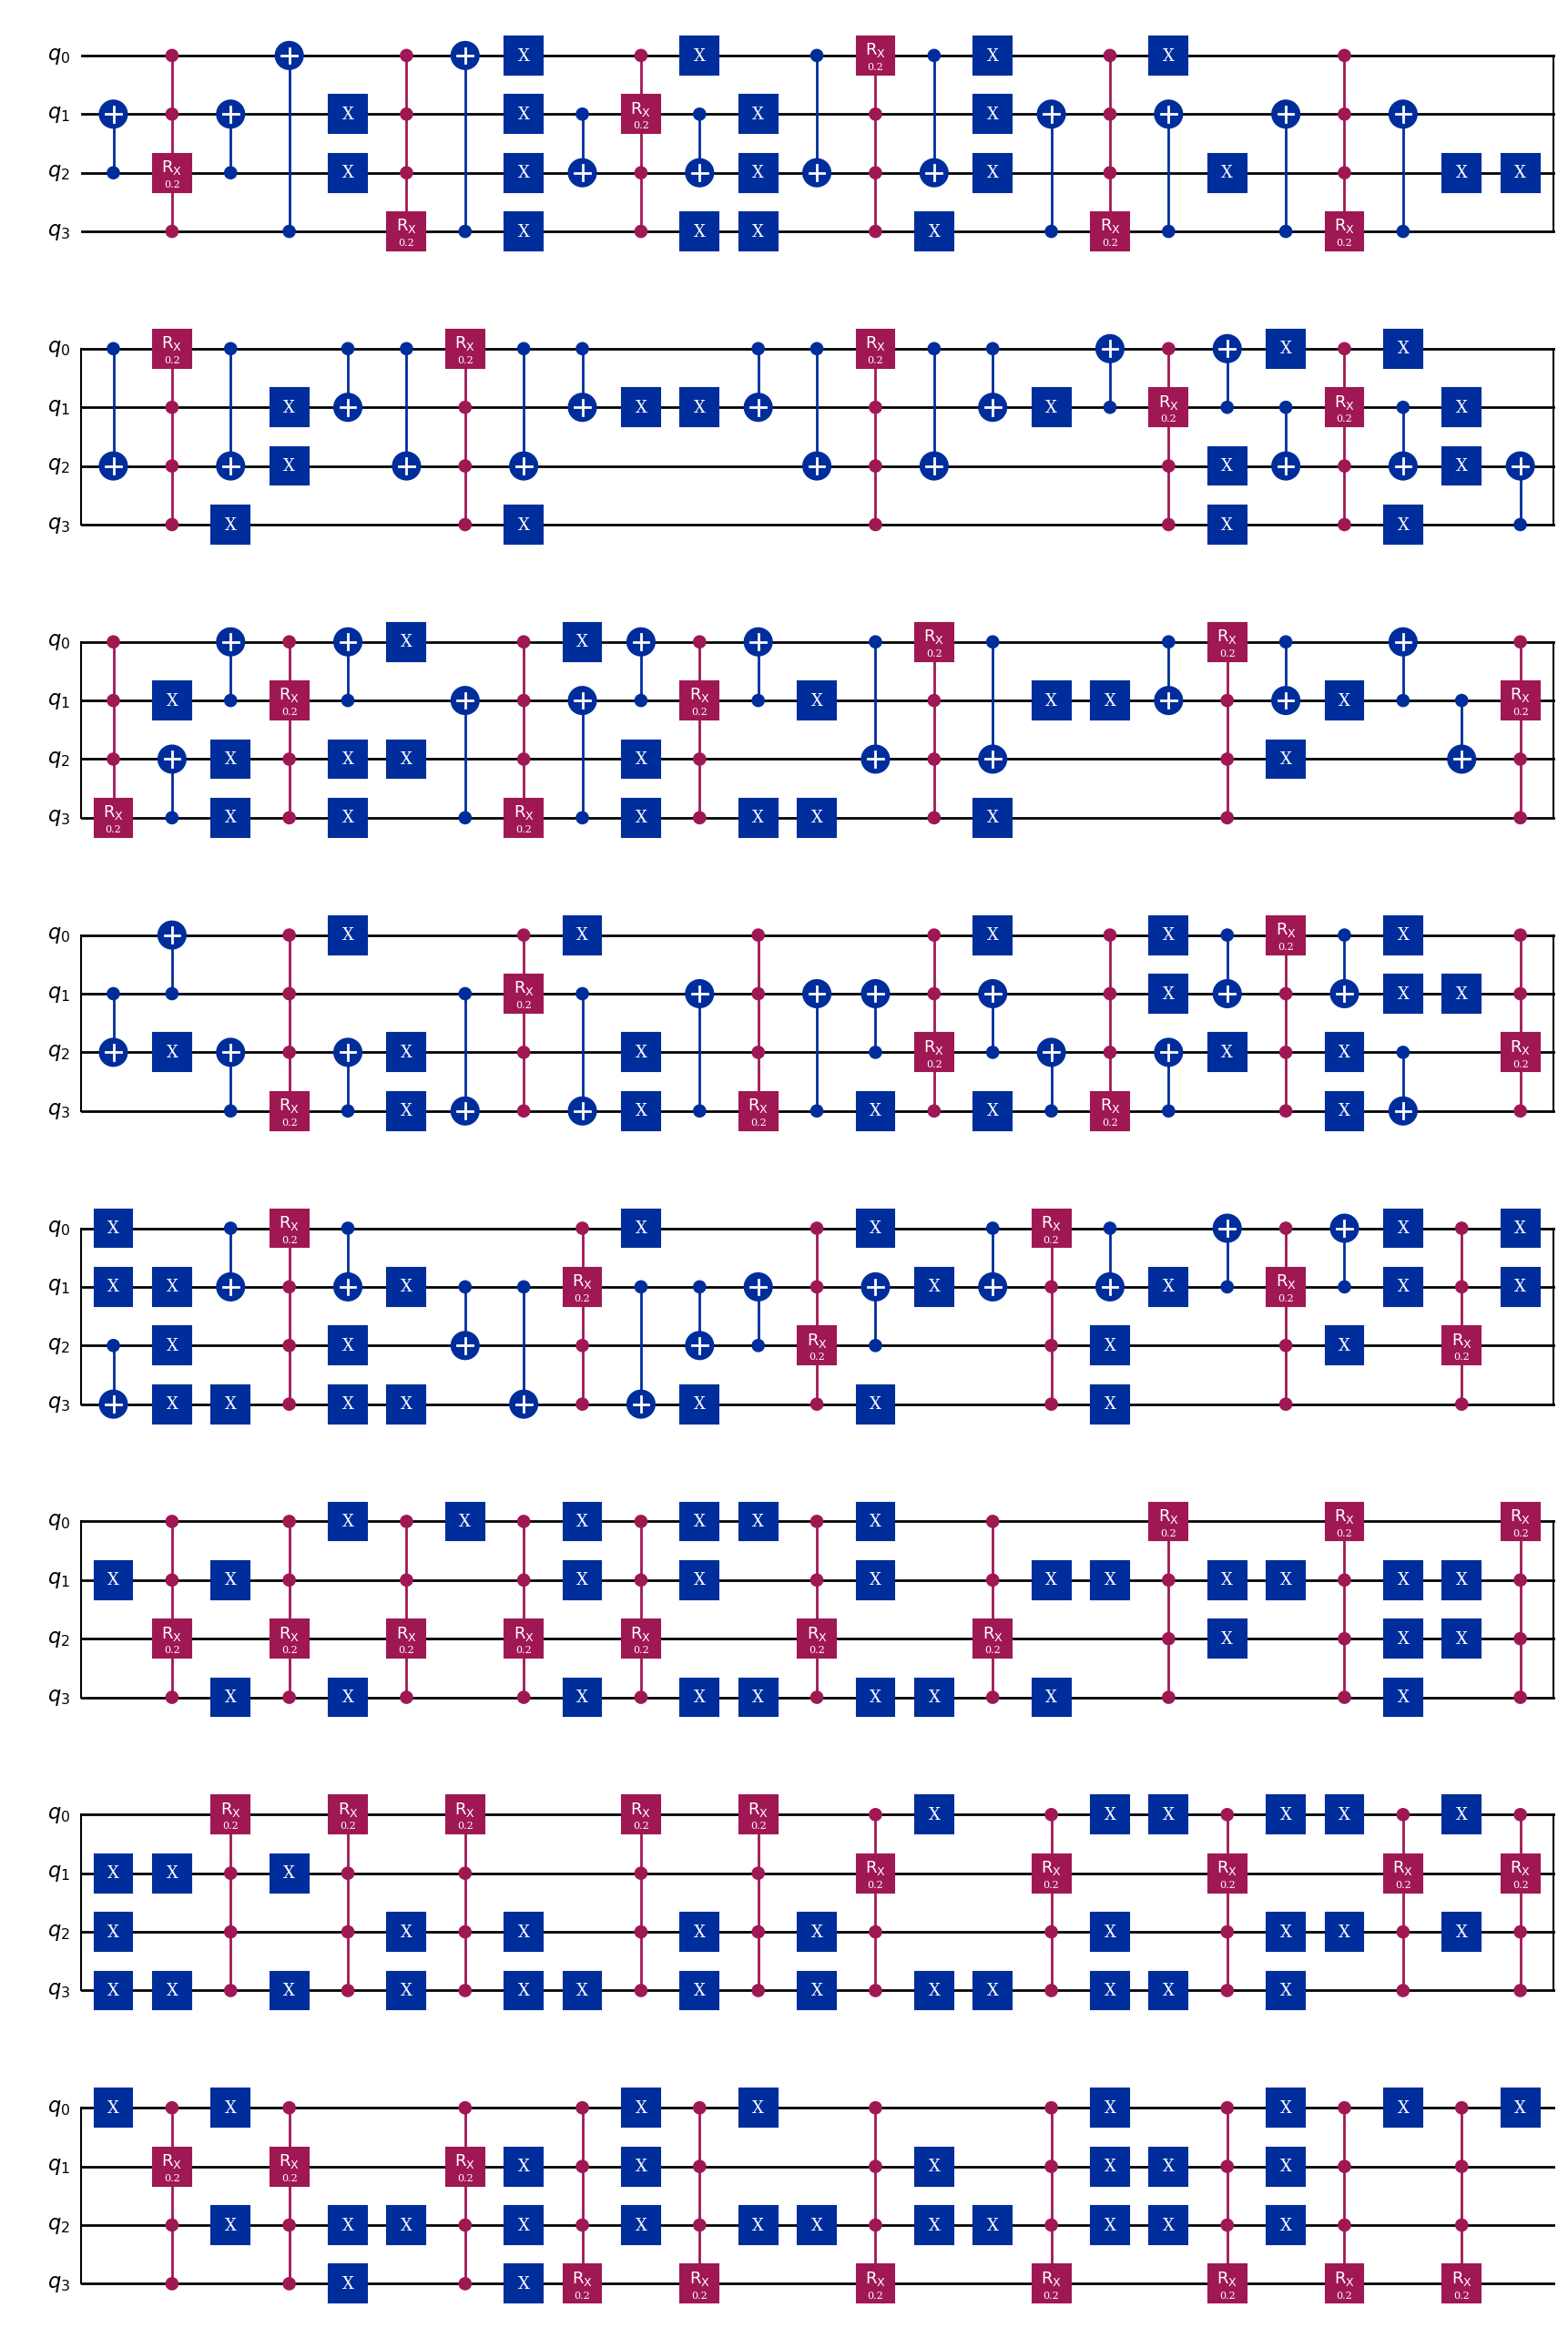


Detailed Gate Count Summary for Dense Non-Bipartite Graph (4 qubits):
n_steps | Matching No Opt (U3/CX/Total) | Matching Opt (U3/CX/Total) | Pauli No Opt (U3/CX/Total) | Pauli Opt (U3/CX/Total)
------------------------------------------------------------------------------------------------------------------------
      1 | 2315/1288/  3603              | 1032/1264/  2296             | 327/252/   579            | 161/ 98/   259
      2 | 4630/2576/  7206              | 2064/2528/  4592             | 654/504/  1158            | 312/196/   508
      5 | 11575/6440/ 18015              | 5160/6320/ 11480             | 1635/1260/  2895            | 792/490/  1282
     10 | 23150/12880/ 36030              | 10310/12640/ 22950             | 3270/2520/  5790            | 1582/980/  2562
     20 | 46300/25760/ 72060              | 20620/25280/ 45900             | 6540/5040/ 11580            | 3162/1960/  5122
     50 | 115750/64400/180150              | 51550/63200/114750             | 16350/12

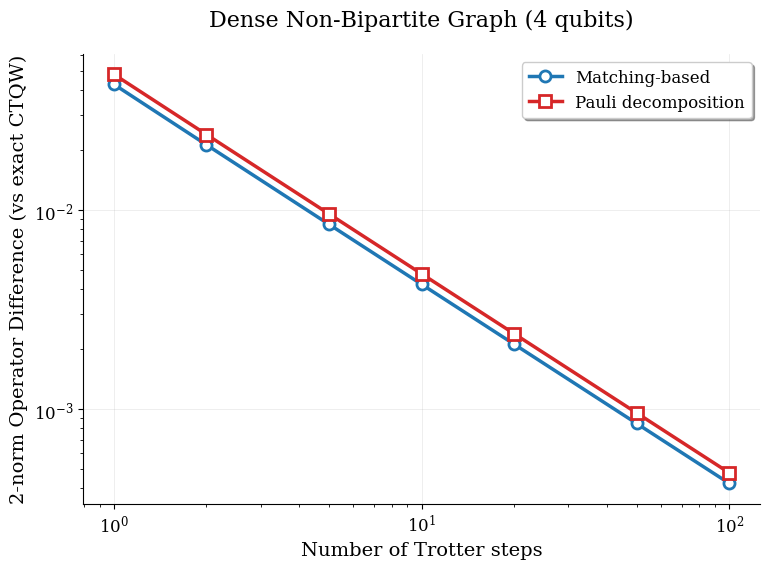

In [13]:
dense_nonbipartite_16 = {
    ('0000','0001'), ('0000','0010'), ('0000','0011'), ('0000','0100'), ('0000','0101'), ('0000','0110'), ('0000','0111'),
    ('0001','0010'), ('0001','0011'), ('0001','0100'), ('0001','0101'), ('0001','1000'), ('0001','1001'),
    ('0010','0011'), ('0010','0100'), ('0010','0110'), ('0010','1000'), ('0010','1010'),
    ('0011','0100'), ('0011','0101'), ('0011','0111'), ('0011','1001'), ('0011','1011'),
    ('0100','0101'), ('0100','0110'), ('0100','1000'), ('0100','1010'), ('0100','1100'),
    ('0101','0110'), ('0101','0111'), ('0101','1001'), ('0101','1011'), ('0101','1101'),
    ('0110','0111'), ('0110','1010'), ('0110','1100'), ('0110','1110'),
    ('0111','1011'), ('0111','1101'), ('0111','1111'),
    ('1000','1001'), ('1000','1010'), ('1000','1011'), ('1000','1100'),
    ('1001','1010'), ('1001','1011'), ('1001','1101'), ('1001','1110'),
    ('1010','1011'), ('1010','1100'), ('1010','1110'), ('1010','1111'),
    ('1011','1100'), ('1011','1101'), ('1011','1111'),
    ('1100','1101'), ('1100','1110'), ('1100','1111'),
    ('1101','1110'), ('1101','1111'),
    ('1110','1111')
}
analyze_and_plot(dense_nonbipartite_16, "Dense Non-Bipartite Graph (4 qubits)")


Dense Bipartite Graph (4 qubits)
Original edges: {('0000', '1011'), ('0110', '1100'), ('0001', '1001'), ('0111', '1000'), ('0011', '1110'), ('0100', '1011'), ('0110', '1001'), ('0010', '1011'), ('0011', '1100'), ('0000', '1010'), ('0000', '1110'), ('0000', '1111'), ('0001', '1010'), ('0000', '1101'), ('0011', '1001'), ('0000', '1100'), ('0001', '1110'), ('0001', '1111'), ('0100', '1010'), ('0101', '1011'), ('0001', '1101'), ('0100', '1110'), ('0100', '1111'), ('0001', '1100'), ('0010', '1010'), ('0110', '1010'), ('0100', '1101'), ('0010', '1110'), ('0010', '1111'), ('0000', '1001'), ('0110', '1111'), ('0100', '1100'), ('0010', '1101'), ('0110', '1101'), ('0010', '1100'), ('0111', '1001'), ('0000', '1000'), ('0101', '1010'), ('0100', '1001'), ('0011', '1010'), ('0111', '1011'), ('0101', '1110'), ('0101', '1111'), ('0011', '1111'), ('0001', '1011'), ('0010', '1001'), ('0001', '1000'), ('0101', '1101'), ('0011', '1101'), ('0101', '1100'), ('0100', '1000'), ('0110', '1011'), ('0010', '100

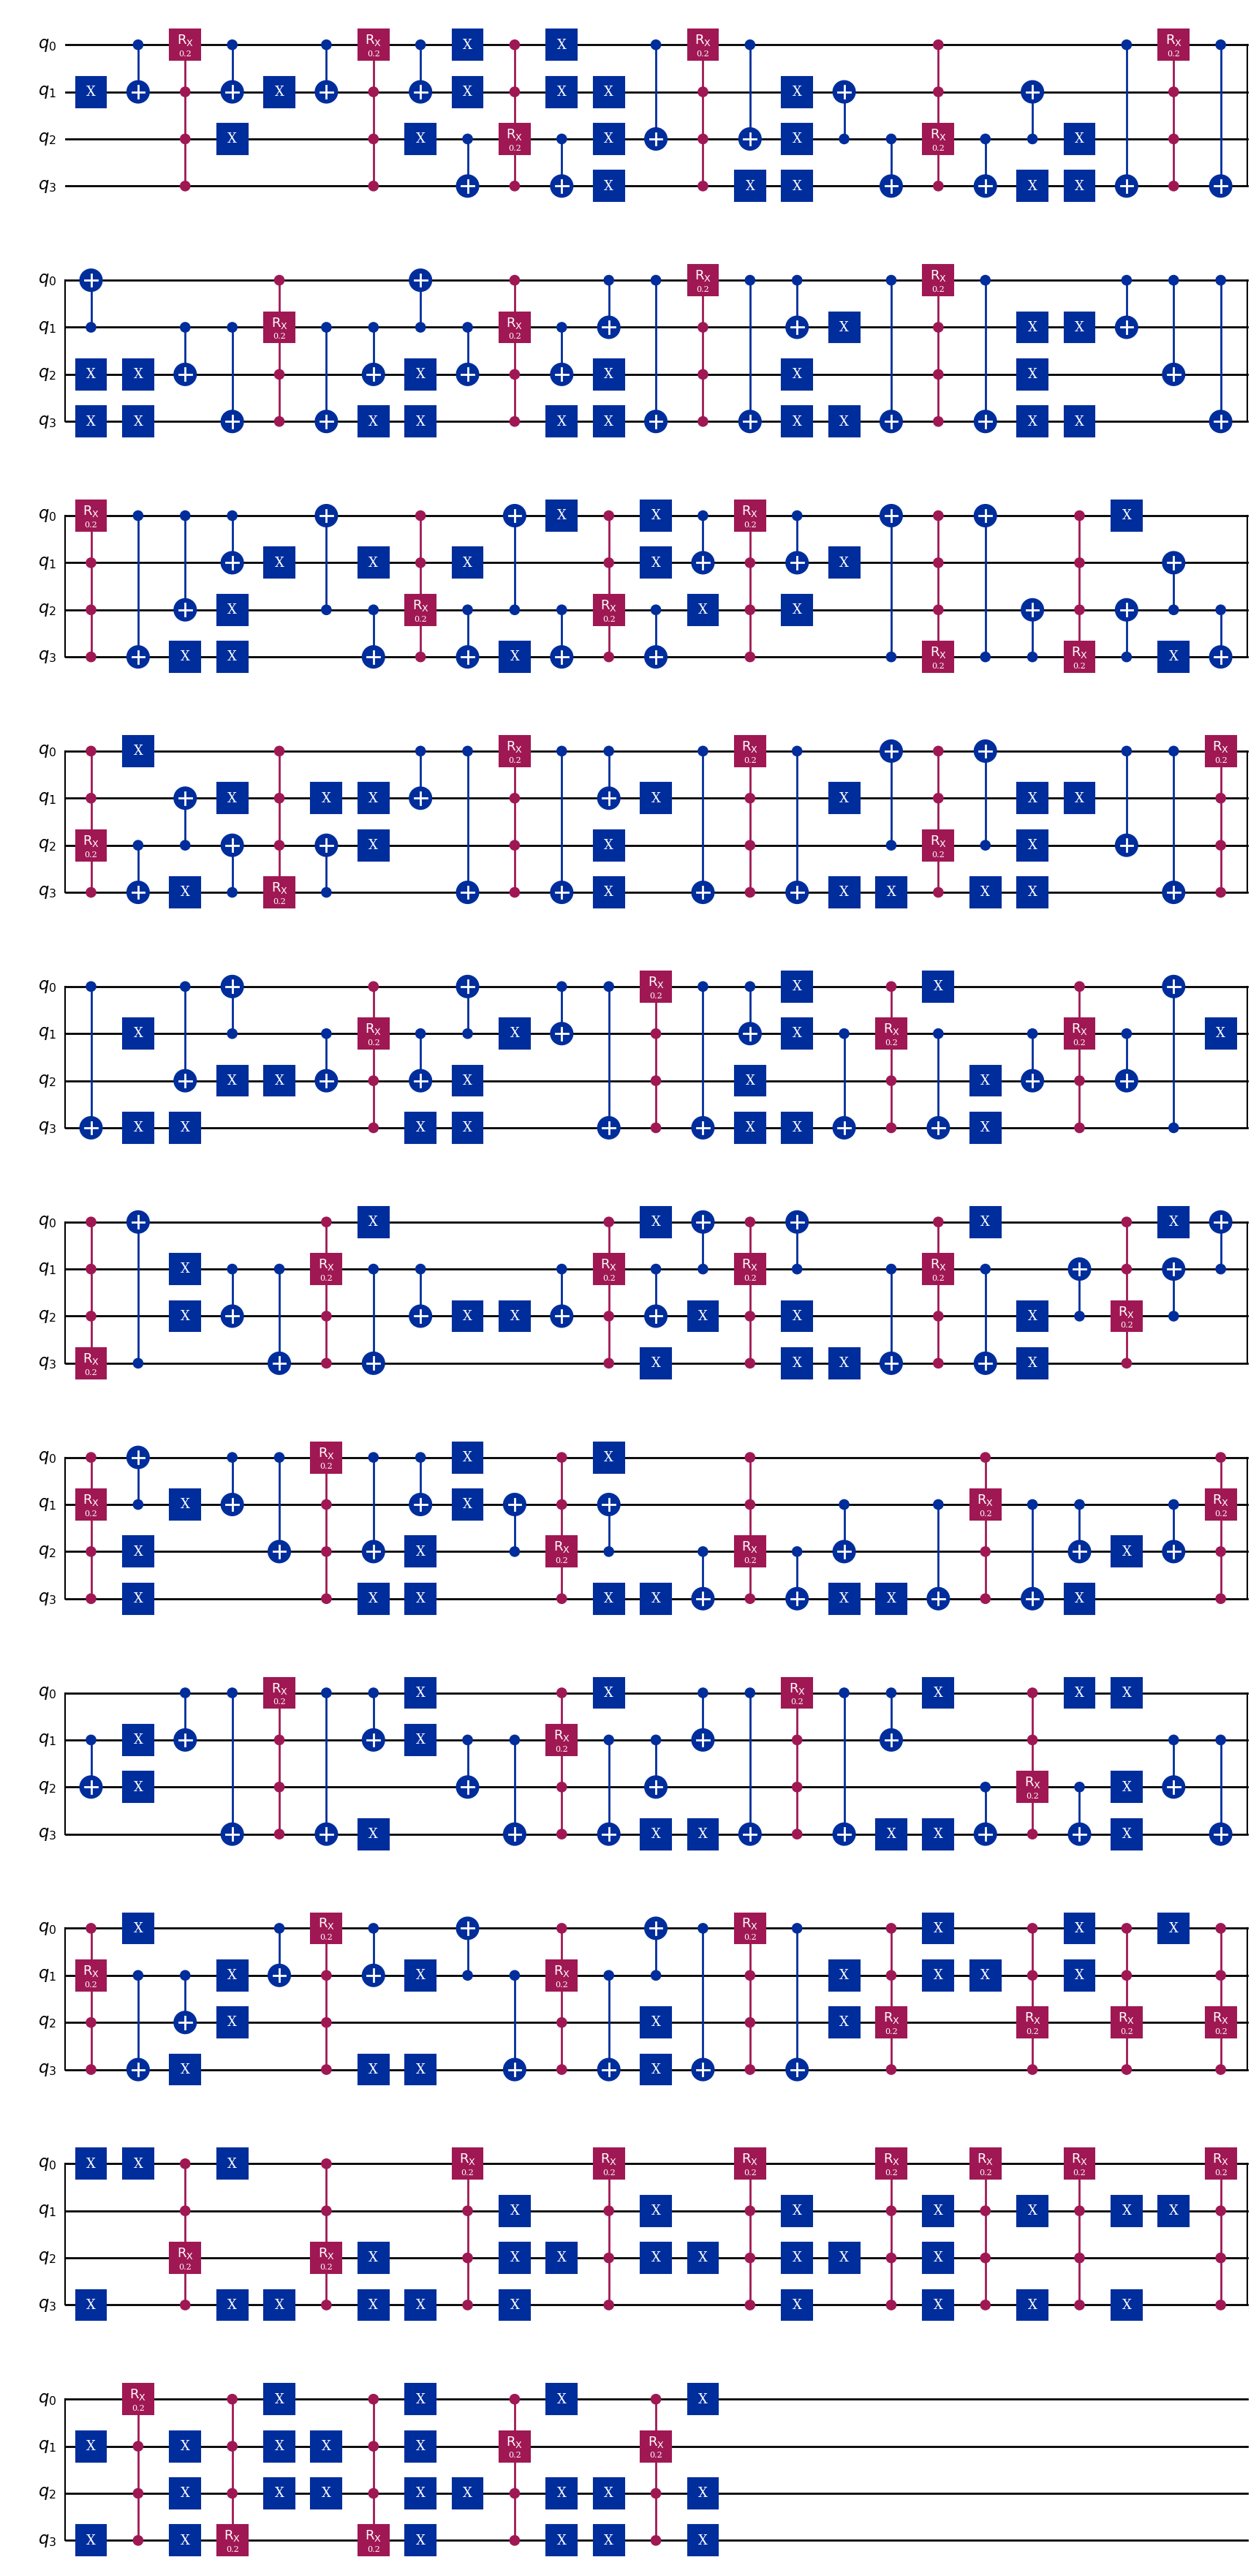


Detailed Gate Count Summary for Dense Bipartite Graph (4 qubits):
n_steps | Matching No Opt (U3/CX/Total) | Matching Opt (U3/CX/Total) | Pauli No Opt (U3/CX/Total) | Pauli Opt (U3/CX/Total)
------------------------------------------------------------------------------------------------------------------------
      1 | 2440/1412/  3852              | 1148/1358/  2506             | 299/208/   507            | 128/ 99/   227
      2 | 4880/2824/  7704              | 2296/2715/  5011             | 598/416/  1014            | 246/198/   444
      5 | 12200/7060/ 19260              | 5740/6786/ 12526             | 1495/1040/  2535            | 622/495/  1117
     10 | 24400/14120/ 38520              | 11490/13571/ 25061             | 2990/2080/  5070            | 1222/990/  2212
     20 | 48800/28240/ 77040              | 22980/27141/ 50121             | 5980/4160/ 10140            | 2482/1980/  4462
     50 | 122000/70600/192600              | 57450/67851/125301             | 14950/10400/

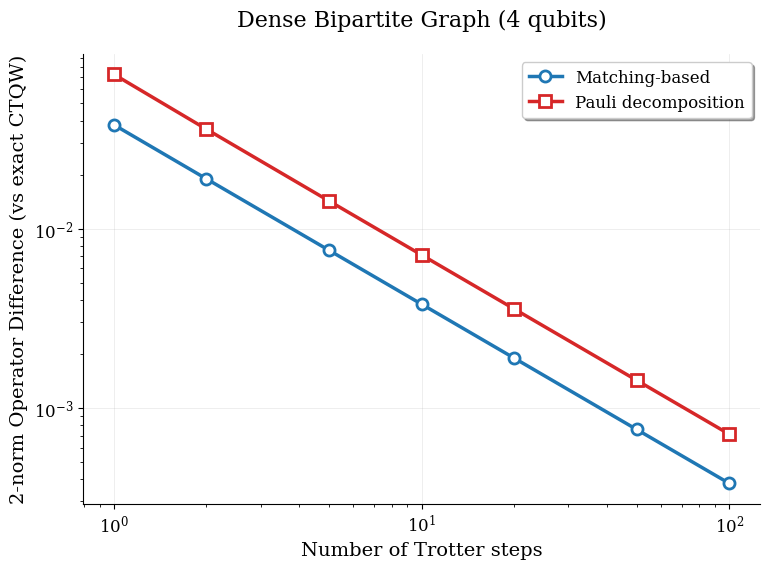

In [14]:
dense_bipartite_16 = {
    ('0000','1000'), ('0000','1001'), ('0000','1010'), ('0000','1011'), ('0000','1100'), ('0000','1101'), ('0000','1110'), ('0000','1111'),
    ('0001','1000'), ('0001','1001'), ('0001','1010'), ('0001','1011'), ('0001','1100'), ('0001','1101'), ('0001','1110'), ('0001','1111'),
    ('0010','1000'), ('0010','1001'), ('0010','1010'), ('0010','1011'), ('0010','1100'), ('0010','1101'), ('0010','1110'), ('0010','1111'),
    ('0011','1000'), ('0011','1001'), ('0011','1010'), ('0011','1011'), ('0011','1100'), ('0011','1101'), ('0011','1110'), ('0011','1111'),
    ('0100','1000'), ('0100','1001'), ('0100','1010'), ('0100','1011'), ('0100','1100'), ('0100','1101'), ('0100','1110'), ('0100','1111'),
    ('0101','1000'), ('0101','1001'), ('0101','1010'), ('0101','1011'), ('0101','1100'), ('0101','1101'), ('0101','1110'), ('0101','1111'),
    ('0110','1000'), ('0110','1001'), ('0110','1010'), ('0110','1011'), ('0110','1100'), ('0110','1101'), ('0110','1110'), ('0110','1111'),
    ('0111','1000'), ('0111','1001'), ('0111','1010'), ('0111','1011'), ('0111','1100'), ('0111','1101'), ('0111','1110'), ('0111','1111')
}

analyze_and_plot(dense_bipartite_16, "Dense Bipartite Graph (4 qubits)")


Sparse Non-Bipartite Graph (4 qubits)
Original edges: {('1100', '1101'), ('1010', '1000'), ('0010', '0000'), ('1011', '1100'), ('0000', '0001'), ('0000', '1000'), ('0110', '0111'), ('0001', '0010'), ('0111', '0011'), ('0101', '0110'), ('1000', '1001'), ('0100', '0101'), ('0011', '1011'), ('1001', '1010'), ('1110', '1111'), ('0011', '0100')}
Number of matchings: 5
Matchings: [{('0111', '0011'), ('1001', '1101'), ('1000', '1100')}, {('1011', '1001'), ('1010', '1000'), ('0010', '0000')}, {('0100', '0101'), ('0000', '0001'), ('0110', '0111'), ('1110', '1111')}, {('0011', '1011'), ('0000', '1000')}, {('0011', '0100'), ('1100', '1010'), ('0101', '0110'), ('0001', '0010')}]
Relabeled edges: {('0011', '0100'), ('1011', '1001'), ('1001', '1101'), ('1000', '1100'), ('1010', '1000'), ('0010', '0000'), ('0101', '0110'), ('1100', '1010'), ('0100', '0101'), ('0011', '1011'), ('1110', '1111'), ('0000', '0001'), ('0000', '1000'), ('0001', '0010'), ('0110', '0111'), ('0111', '0011')}
Number of qubits:

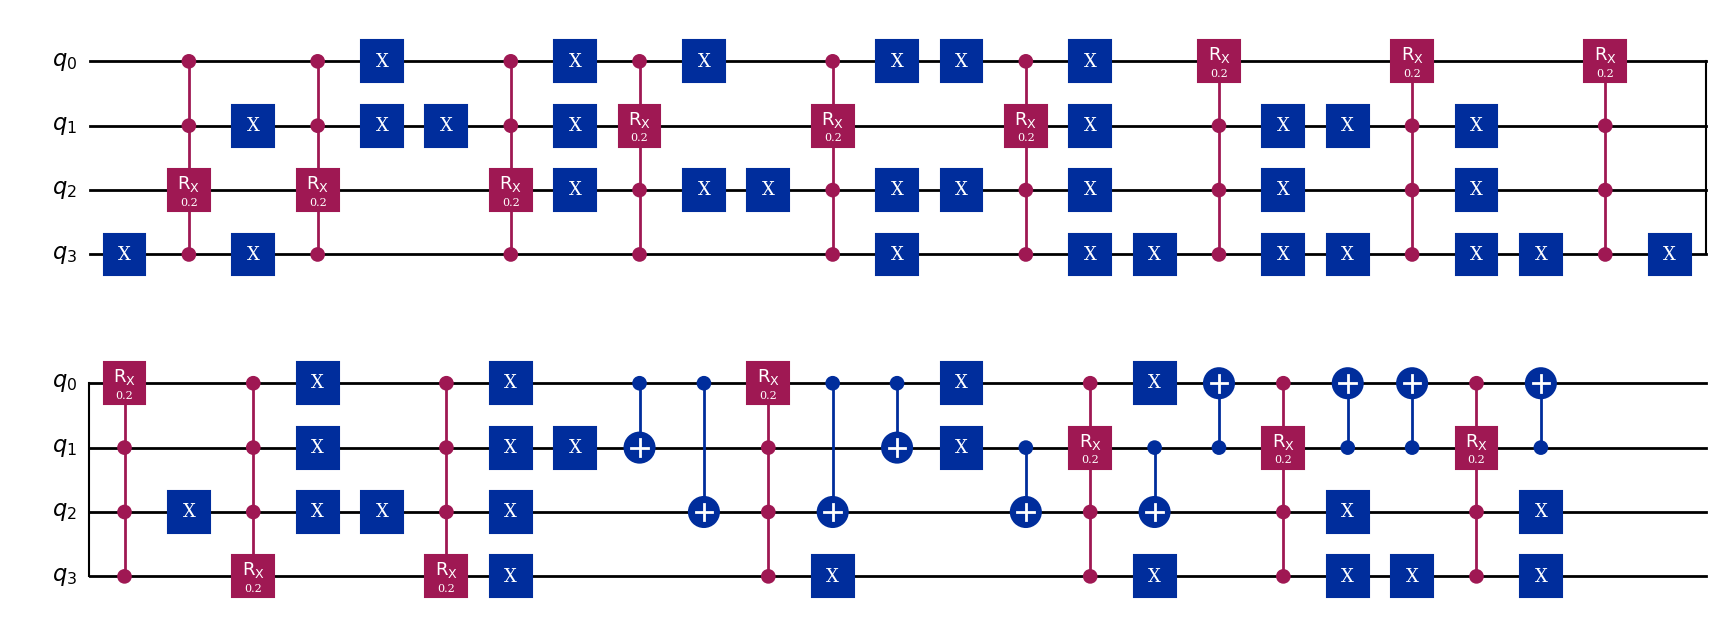


Detailed Gate Count Summary for Sparse Non-Bipartite Graph (4 qubits):
n_steps | Matching No Opt (U3/CX/Total) | Matching Opt (U3/CX/Total) | Pauli No Opt (U3/CX/Total) | Pauli Opt (U3/CX/Total)
------------------------------------------------------------------------------------------------------------------------
      1 | 612/330/   942              | 259/327/   586             | 183/156/   339            | 111/ 69/   180
      2 | 1224/660/  1884              | 515/654/  1169             | 366/312/   678            | 219/138/   357
      5 | 3060/1650/  4710              | 1283/1635/  2918             | 915/780/  1695            | 551/345/   896
     10 | 6120/3300/  9420              | 2563/3270/  5833             | 1830/1560/  3390            | 1101/690/  1791
     20 | 12240/6600/ 18840              | 5123/6540/ 11663             | 3660/3120/  6780            | 2221/1380/  3601
     50 | 30600/16500/ 47100              | 12803/16350/ 29153             | 9150/7800/ 16950         

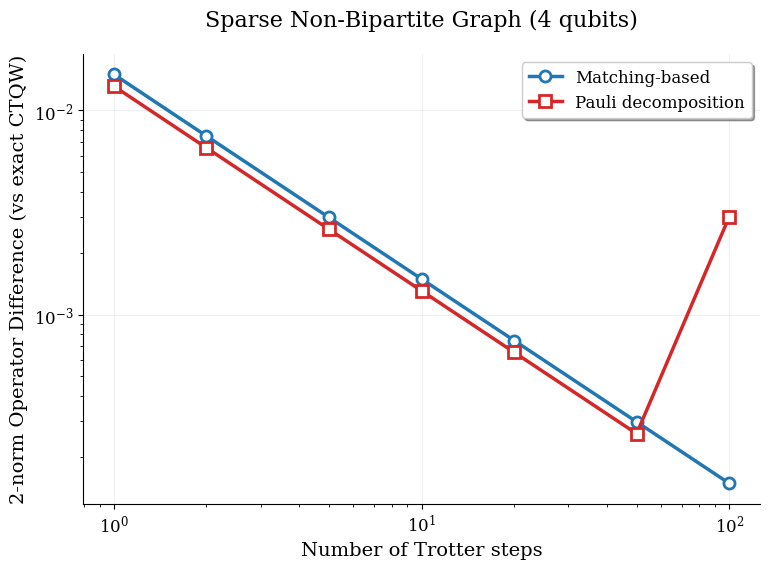

In [15]:
sparse_nonbipartite_16 = {
    ('0000','0001'), ('0001','0010'), ('0010','0000'),           # Triangle
    ('0011','0100'), ('0100','0101'), ('0101','0110'), ('0110','0111'), ('0111','0011'),  # Pentagon
    ('1000','1001'), ('1001','1010'), ('1010','1000'),         # Triangle
    ('1011','1100'), ('1100','1101'),
    ('1110','1111'),
    ('0000','1000'), ('0011','1011')  # Connecting components
}

analyze_and_plot(sparse_nonbipartite_16, "Sparse Non-Bipartite Graph (4 qubits)")


Sparse Bipartite Graph (4 qubits)
Original edges: {('0010', '0001'), ('0110', '0101'), ('0100', '0011'), ('1010', '1101'), ('0100', '0111'), ('1010', '1001'), ('0000', '0011'), ('0110', '1001'), ('1000', '0111'), ('0000', '0001'), ('1100', '1111'), ('1000', '1011'), ('0010', '0101'), ('1100', '1011'), ('1110', '1101')}
Number of matchings: 2
Matchings: [{('0011', '0010'), ('1011', '1010'), ('1001', '1000'), ('0001', '0000'), ('1110', '1111'), ('0101', '0100'), ('0110', '0111'), ('1101', '1100')}, {('0011', '1000'), ('0110', '1100'), ('1101', '0010'), ('0001', '1010'), ('0101', '0000'), ('1011', '0111'), ('1001', '1111')}]
Relabeled edges: {('0011', '0010'), ('1011', '1010'), ('1001', '1000'), ('0001', '0000'), ('0011', '1000'), ('0110', '1100'), ('1101', '0010'), ('0001', '1010'), ('1110', '1111'), ('0101', '0000'), ('1011', '0111'), ('0101', '0100'), ('1001', '1111'), ('0110', '0111'), ('1101', '1100')}
Number of qubits: 4

Sample Quantum Circuit (n_steps=1):


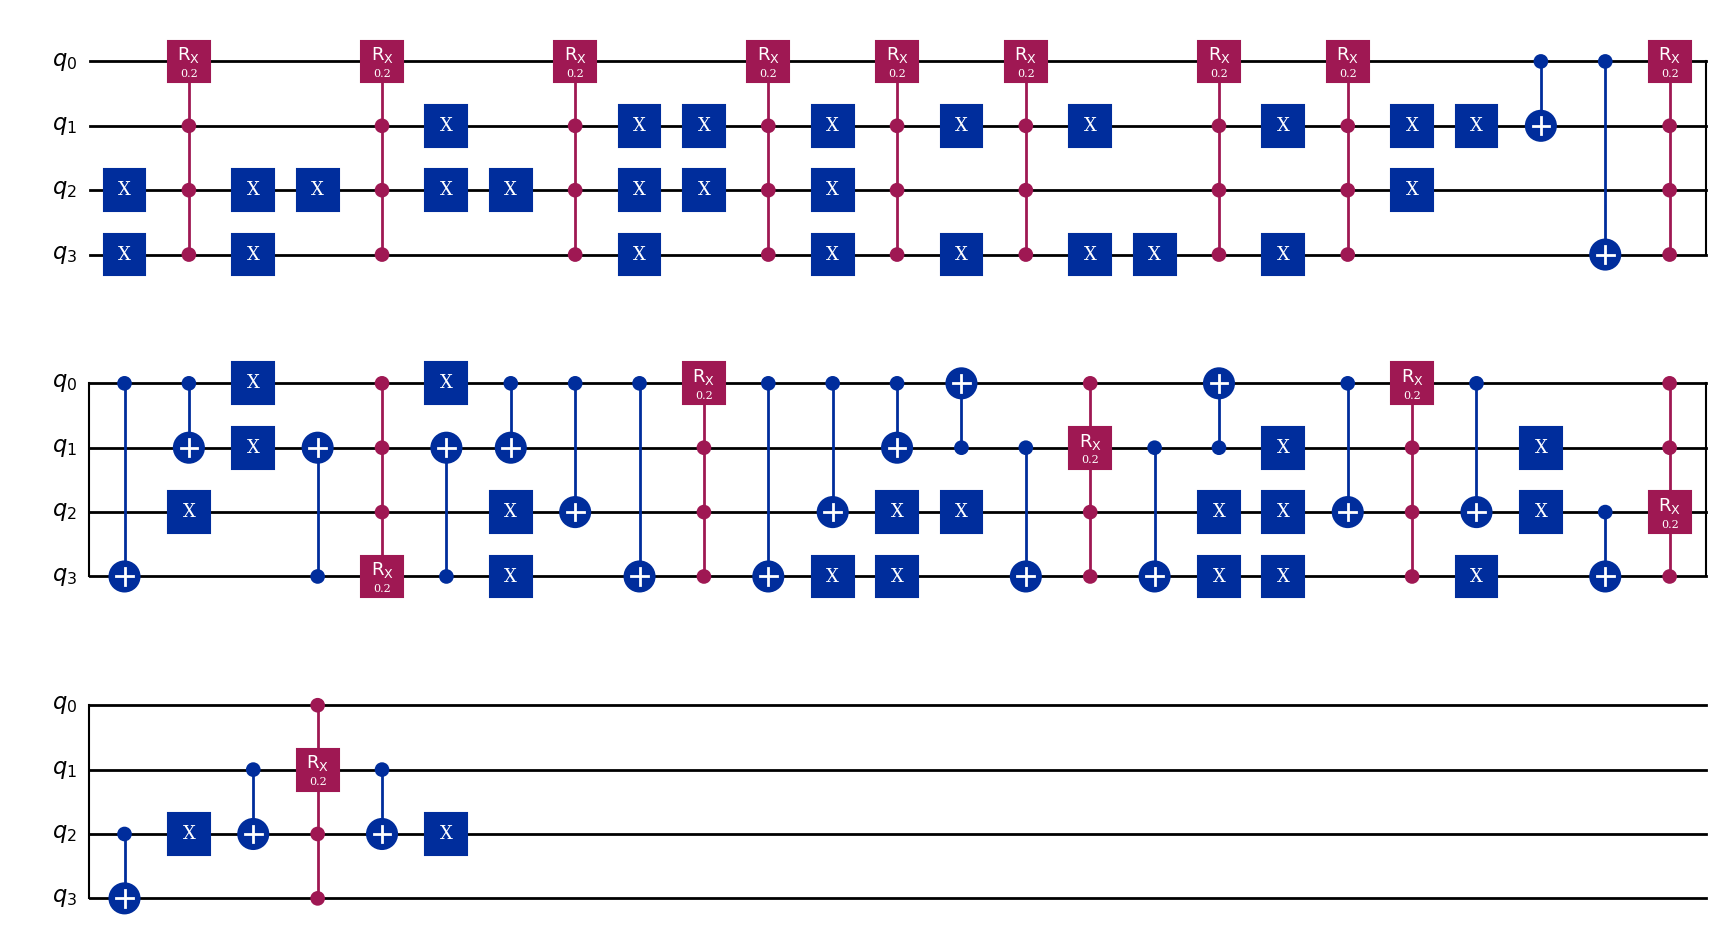


Detailed Gate Count Summary for Sparse Bipartite Graph (4 qubits):
n_steps | Matching No Opt (U3/CX/Total) | Matching Opt (U3/CX/Total) | Pauli No Opt (U3/CX/Total) | Pauli Opt (U3/CX/Total)
------------------------------------------------------------------------------------------------------------------------
      1 | 571/322/   893              | 255/317/   572             | 261/196/   457            | 144/ 93/   237
      2 | 1142/644/  1786              | 508/634/  1142             | 522/392/   914            | 284/186/   470
      5 | 2855/1610/  4465              | 1267/1585/  2852             | 1305/980/  2285            | 712/465/  1177
     10 | 5710/3220/  8930              | 2532/3170/  5702             | 2610/1960/  4570            | 1440/930/  2370
     20 | 11420/6440/ 17860              | 5062/6340/ 11402             | 5220/3920/  9140            | 2860/1860/  4720
     50 | 28550/16100/ 44650              | 12652/15850/ 28502             | 13050/9800/ 22850           

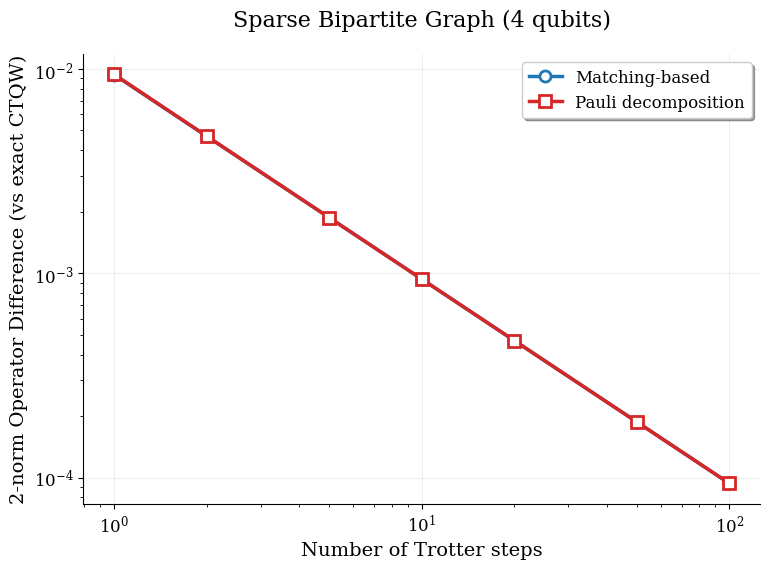

In [16]:
sparse_bipartite_16 = {
    ('0000','0001'), ('0000','0011'),
    ('0010','0001'), ('0010','0101'),
    ('0100','0011'), ('0100','0111'),
    ('0110','0101'), ('0110','1001'),
    ('1000','0111'), ('1000','1011'),
    ('1010','1001'), ('1010','1101'),
    ('1100','1011'), ('1100','1111'),
    ('1110','1101')
}
analyze_and_plot(sparse_bipartite_16, "Sparse Bipartite Graph (4 qubits)")